In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [2]:
miami_hialeah_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\Miami_and_Hialeah_alltraps.xlsx"

df_mh = pd.read_excel(miami_hialeah_path)

df_mh["Date_Submitted"] = pd.to_datetime(df_mh["Date_Submitted"])

df_mh.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-09-27,2,CW20,Miami
1,2016-10-04,1,CW20,Miami
2,2016-10-11,3,CW20,Miami
3,2016-10-18,1,CW20,Miami
4,2016-11-01,3,CW20,Miami


In [3]:
full_dataset_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\cleandata_alltraps_culex.csv"
df_full = pd.read_csv(full_dataset_path)

df_full["Date_Submitted"] = pd.to_datetime(df_full["Date_Submitted"])

df_full.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,LOCATION
0,2016-09-20,30,CW6,23941 SW 112 Ct
1,2016-09-23,30,CW6,23941 SW 112 Ct
2,2016-09-27,15,CW6,23941 SW 112 Ct
3,2016-09-29,15,CW6,23941 SW 112 Ct
4,2016-10-18,11,CW6,23941 SW 112 Ct


In [4]:
def create_weekly_series(df, date_col, value_col):
    ts = (
        df.set_index(date_col)
        .resample("W")[value_col]
        .sum()
        .to_frame(name="mosquito_count")
    )

    ts["mosquito_count"] = ts["mosquito_count"].fillna(0)

    return ts

In [5]:
miami_df = df_mh[df_mh["City"].str.upper() == "MIAMI"].copy()

miami_ts = create_weekly_series(
    miami_df,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

miami_ts.head()

,mosquito_count
Date_Submitted,
2016-01-10,5
2016-01-17,9
2016-01-24,5
2016-01-31,11
2016-02-07,0


In [6]:
hialeah_df = df_mh[df_mh["City"].str.upper() == "HIALEAH"].copy()

hialeah_ts = create_weekly_series(
    hialeah_df,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

hialeah_ts.head()

,mosquito_count
Date_Submitted,
2016-08-21,1
2016-08-28,6
2016-09-04,1
2016-09-11,17
2016-09-18,46


In [7]:
full_ts = create_weekly_series(
    df_full,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

full_ts.head()

,mosquito_count
Date_Submitted,
2016-01-10,12
2016-01-17,27
2016-01-24,18
2016-01-31,11
2016-02-07,0


In [8]:
def compute_outbreak_thresholds(ts):
    values = ts["mosquito_count"]

    threshold_80 = values.quantile(0.80)
    threshold_90 = values.quantile(0.90)
    threshold_std = values.mean() + values.std()

    return {
        "80th Percentile": threshold_80,
        "90th Percentile": threshold_90,
        "Mean + 1 SD": threshold_std
    }

In [9]:
miami_thresholds = compute_outbreak_thresholds(miami_ts)

miami_thresholds_df = pd.DataFrame({
    "Threshold Type": list(miami_thresholds.keys()),
    "Threshold Value": list(miami_thresholds.values())
})

miami_thresholds_df

,Threshold Type,Threshold Value
0,80th Percentile,1660.600000
1,90th Percentile,2515.000000
2,Mean + 1 SD,2131.285855


In [10]:
hialeah_thresholds = compute_outbreak_thresholds(hialeah_ts)

hialeah_thresholds_df = pd.DataFrame({
    "Threshold Type": list(hialeah_thresholds.keys()),
    "Threshold Value": list(hialeah_thresholds.values())
})

hialeah_thresholds_df

,Threshold Type,Threshold Value
0,80th Percentile,341.800000
1,90th Percentile,569.800000
2,Mean + 1 SD,487.187821


In [11]:
full_thresholds = compute_outbreak_thresholds(full_ts)

full_thresholds_df = pd.DataFrame({
    "Threshold Type": list(full_thresholds.keys()),
    "Threshold Value": list(full_thresholds.values())
})

full_thresholds_df

,Threshold Type,Threshold Value
0,80th Percentile,3932.600000
1,90th Percentile,5263.200000
2,Mean + 1 SD,4654.358506


In [12]:
def add_outbreak_labels(ts):
    ts = ts.copy()

    threshold_80 = ts["mosquito_count"].quantile(0.80)
    threshold_90 = ts["mosquito_count"].quantile(0.90)
    threshold_std = (
        ts["mosquito_count"].mean() +
        ts["mosquito_count"].std()
    )

    ts["outbreak_80"] = (
        ts["mosquito_count"] >= threshold_80
    ).astype(int)

    ts["outbreak_90"] = (
        ts["mosquito_count"] >= threshold_90
    ).astype(int)

    ts["outbreak_std"] = (
        ts["mosquito_count"] >= threshold_std
    ).astype(int)

    return ts


miami_ts = add_outbreak_labels(miami_ts)
hialeah_ts = add_outbreak_labels(hialeah_ts)
full_ts = add_outbreak_labels(full_ts)

In [13]:
def outbreak_frequency_summary(ts, city_name):
    total_weeks = len(ts)

    results = []

    for col in ["outbreak_80", "outbreak_90", "outbreak_std"]:
        outbreak_weeks = ts[col].sum()

        results.append({
            "Series": city_name,
            "Definition": col,
            "Outbreak Weeks": outbreak_weeks,
            "Percent of Weeks": (outbreak_weeks / total_weeks) * 100
        })

    return pd.DataFrame(results)

In [14]:
miami_outbreak_summary = outbreak_frequency_summary(
    miami_ts,
    "Miami"
)

miami_outbreak_summary

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Miami,outbreak_80,62,20.064725
1,Miami,outbreak_90,31,10.032362
2,Miami,outbreak_std,40,12.944984


In [15]:
hialeah_outbreak_summary = outbreak_frequency_summary(
    hialeah_ts,
    "Hialeah"
)

hialeah_outbreak_summary

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Hialeah,outbreak_80,55,20.146520
1,Hialeah,outbreak_90,28,10.256410
2,Hialeah,outbreak_std,39,14.285714


In [16]:
full_outbreak_summary = outbreak_frequency_summary(
    full_ts,
    "Full Dataset"
)

full_outbreak_summary

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Full Dataset,outbreak_80,62,20.064725
1,Full Dataset,outbreak_90,31,10.032362
2,Full Dataset,outbreak_std,40,12.944984


In [17]:
combined_outbreak_summary = pd.concat([
    miami_outbreak_summary,
    hialeah_outbreak_summary,
    full_outbreak_summary
]).reset_index(drop=True)

combined_outbreak_summary

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Miami,outbreak_80,62,20.064725
1,Miami,outbreak_90,31,10.032362
2,Miami,outbreak_std,40,12.944984
3,Hialeah,outbreak_80,55,20.146520
4,Hialeah,outbreak_90,28,10.256410
5,Hialeah,outbreak_std,39,14.285714
6,Full Dataset,outbreak_80,62,20.064725
7,Full Dataset,outbreak_90,31,10.032362
8,Full Dataset,outbreak_std,40,12.944984


In [18]:
combined_outbreak_summary.style.format({
    "Percent of Weeks": "{:.2f}"
})

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Miami,outbreak_80,62,20.06
1,Miami,outbreak_90,31,10.03
2,Miami,outbreak_std,40,12.94
3,Hialeah,outbreak_80,55,20.15
4,Hialeah,outbreak_90,28,10.26
5,Hialeah,outbreak_std,39,14.29
6,Full Dataset,outbreak_80,62,20.06
7,Full Dataset,outbreak_90,31,10.03
8,Full Dataset,outbreak_std,40,12.94


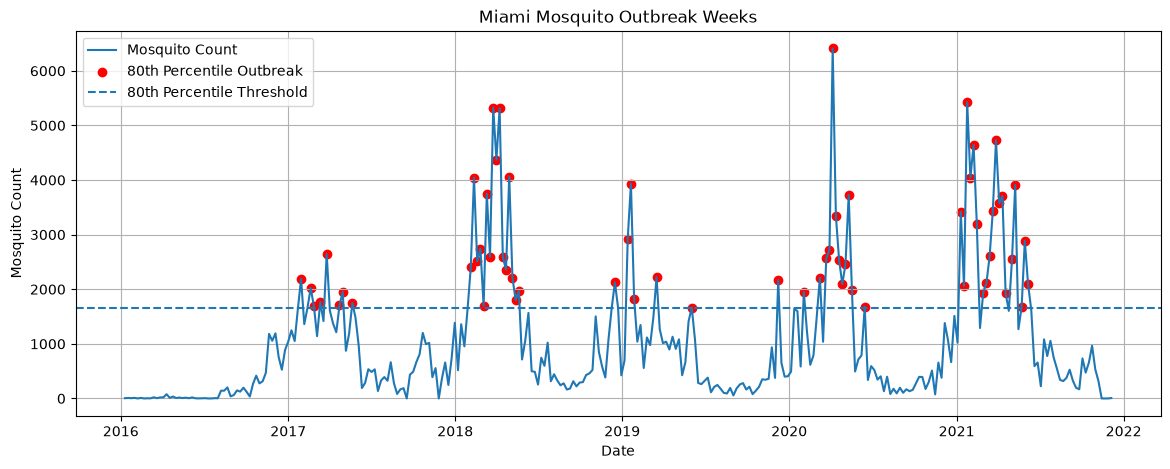

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    miami_ts.index,
    miami_ts["mosquito_count"],
    label="Mosquito Count"
)

outbreak_points = miami_ts[miami_ts["outbreak_80"] == 1]

plt.scatter(
    outbreak_points.index,
    outbreak_points["mosquito_count"],
    color="red",
    label="80th Percentile Outbreak"
)

plt.axhline(
    miami_ts["mosquito_count"].quantile(0.80),
    linestyle="--",
    label="80th Percentile Threshold"
)

plt.title("Miami Mosquito Outbreak Weeks")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

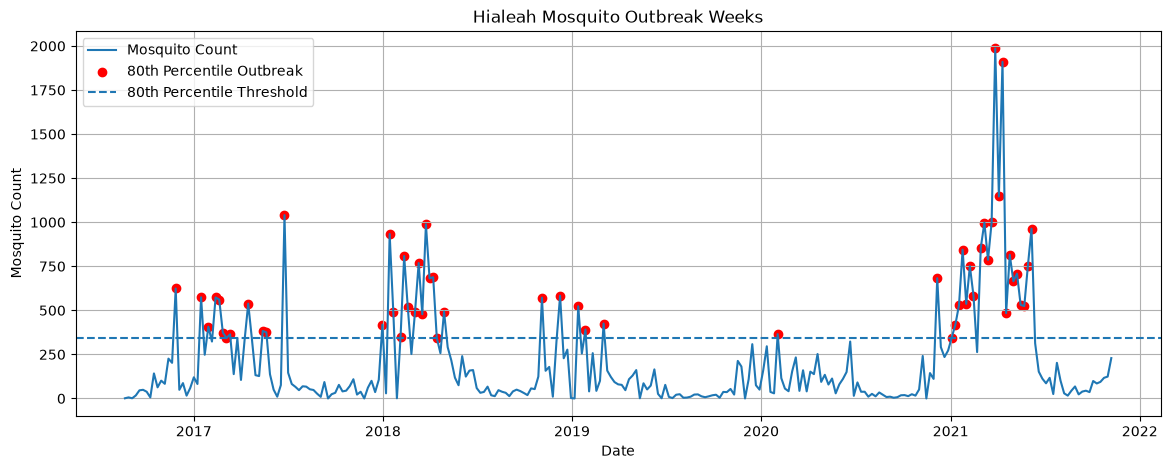

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    hialeah_ts.index,
    hialeah_ts["mosquito_count"],
    label="Mosquito Count"
)

outbreak_points = hialeah_ts[hialeah_ts["outbreak_80"] == 1]

plt.scatter(
    outbreak_points.index,
    outbreak_points["mosquito_count"],
    color="red",
    label="80th Percentile Outbreak"
)

plt.axhline(
    hialeah_ts["mosquito_count"].quantile(0.80),
    linestyle="--",
    label="80th Percentile Threshold"
)

plt.title("Hialeah Mosquito Outbreak Weeks")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

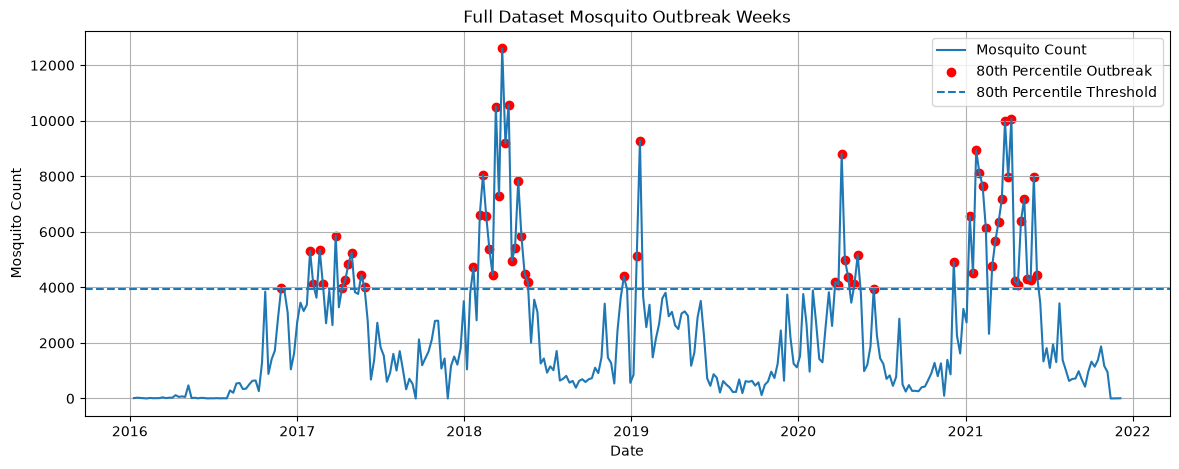

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    full_ts.index,
    full_ts["mosquito_count"],
    label="Mosquito Count"
)

outbreak_points = full_ts[full_ts["outbreak_80"] == 1]

plt.scatter(
    outbreak_points.index,
    outbreak_points["mosquito_count"],
    color="red",
    label="80th Percentile Outbreak"
)

plt.axhline(
    full_ts["mosquito_count"].quantile(0.80),
    linestyle="--",
    label="80th Percentile Threshold"
)

plt.title("Full Dataset Mosquito Outbreak Weeks")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

In [22]:
threshold_comparison = pd.DataFrame({
    "Series": ["Miami", "Hialeah", "Full Dataset"],

    "80th Percentile": [
        miami_ts["mosquito_count"].quantile(0.80),
        hialeah_ts["mosquito_count"].quantile(0.80),
        full_ts["mosquito_count"].quantile(0.80)
    ],

    "90th Percentile": [
        miami_ts["mosquito_count"].quantile(0.90),
        hialeah_ts["mosquito_count"].quantile(0.90),
        full_ts["mosquito_count"].quantile(0.90)
    ],

    "Mean + 1 SD": [
        miami_ts["mosquito_count"].mean() + miami_ts["mosquito_count"].std(),
        hialeah_ts["mosquito_count"].mean() + hialeah_ts["mosquito_count"].std(),
        full_ts["mosquito_count"].mean() + full_ts["mosquito_count"].std()
    ]
})

threshold_comparison

,Series,80th Percentile,90th Percentile,Mean + 1 SD
0,Miami,1660.6,2515.0,2131.285855
1,Hialeah,341.8,569.8,487.187821
2,Full Dataset,3932.6,5263.2,4654.358506


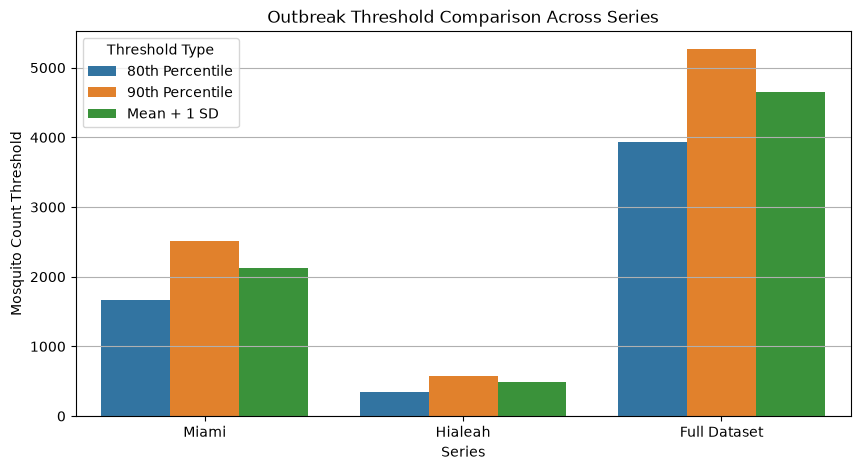

In [23]:
threshold_melted = threshold_comparison.melt(
    id_vars="Series",
    var_name="Threshold Type",
    value_name="Threshold Value"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=threshold_melted,
    x="Series",
    y="Threshold Value",
    hue="Threshold Type"
)

plt.title("Outbreak Threshold Comparison Across Series")
plt.ylabel("Mosquito Count Threshold")
plt.show()

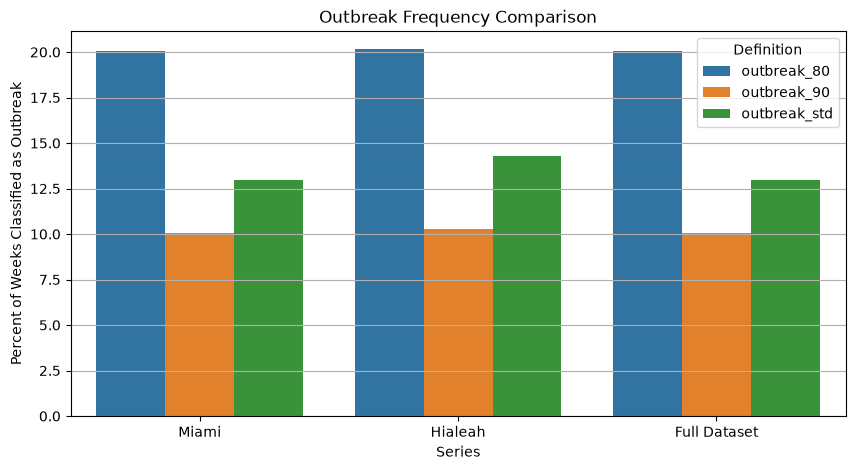

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=combined_outbreak_summary,
    x="Series",
    y="Percent of Weeks",
    hue="Definition"
)

plt.title("Outbreak Frequency Comparison")
plt.ylabel("Percent of Weeks Classified as Outbreak")
plt.show()

In [25]:
def outbreak_duration_analysis(ts, outbreak_col, series_name):
    """
    Finds consecutive outbreak waves and summarizes their duration.
    """
    ts = ts.copy()
    ts["outbreak_group"] = (
        ts[outbreak_col].ne(ts[outbreak_col].shift()).cumsum()
    )

    outbreak_groups = (
        ts[ts[outbreak_col] == 1]
        .groupby("outbreak_group")
        .agg(
            start_date=("mosquito_count", lambda x: x.index.min()),
            end_date=("mosquito_count", lambda x: x.index.max()),
            duration_weeks=("mosquito_count", "size"),
            peak_count=("mosquito_count", "max"),
            mean_count=("mosquito_count", "mean")
        )
        .reset_index(drop=True)
    )

    if outbreak_groups.empty:
        summary = {
            "Series": series_name,
            "Outbreak Definition": outbreak_col,
            "Number of Outbreak Waves": 0,
            "Average Duration (weeks)": np.nan,
            "Median Duration (weeks)": np.nan,
            "Longest Duration (weeks)": np.nan,
            "Average Peak Count": np.nan
        }
    else:
        summary = {
            "Series": series_name,
            "Outbreak Definition": outbreak_col,
            "Number of Outbreak Waves": len(outbreak_groups),
            "Average Duration (weeks)": outbreak_groups["duration_weeks"].mean(),
            "Median Duration (weeks)": outbreak_groups["duration_weeks"].median(),
            "Longest Duration (weeks)": outbreak_groups["duration_weeks"].max(),
            "Average Peak Count": outbreak_groups["peak_count"].mean()
        }

    return outbreak_groups, summary

In [26]:
miami_outbreak_waves, miami_duration_summary = outbreak_duration_analysis(
    miami_ts,
    outbreak_col="outbreak_80",
    series_name="Miami"
)

display(miami_outbreak_waves.head())
miami_duration_summary

,start_date,end_date,duration_weeks,peak_count,mean_count
0,2017-01-29,2017-01-29,1,2188,2188.0
1,2017-02-19,2017-02-26,2,2023,1858.5
2,2017-03-12,2017-03-12,1,1768,1768.0
3,2017-03-26,2017-03-26,1,2642,2642.0
4,2017-04-23,2017-04-30,2,1951,1827.5


{'Series': 'Miami',
 'Outbreak Definition': 'outbreak_80',
 'Number of Outbreak Waves': 20,
 'Average Duration (weeks)': np.float64(3.1),
 'Median Duration (weeks)': np.float64(1.0),
 'Longest Duration (weeks)': np.int64(16),
 'Average Peak Count': np.float64(2948.05)}

In [27]:
hialeah_outbreak_waves, hialeah_duration_summary = outbreak_duration_analysis(
    hialeah_ts,
    outbreak_col="outbreak_80",
    series_name="Hialeah"
)

display(hialeah_outbreak_waves.head())
hialeah_duration_summary

,start_date,end_date,duration_weeks,peak_count,mean_count
0,2016-11-27,2016-11-27,1,624,624.0
1,2017-01-15,2017-01-15,1,574,574.0
2,2017-01-29,2017-01-29,1,407,407.0
3,2017-02-12,2017-03-12,5,573,443.0
4,2017-04-16,2017-04-16,1,538,538.0


{'Series': 'Hialeah',
 'Outbreak Definition': 'outbreak_80',
 'Number of Outbreak Waves': 21,
 'Average Duration (weeks)': np.float64(2.619047619047619),
 'Median Duration (weeks)': np.float64(1.0),
 'Longest Duration (weeks)': np.int64(15),
 'Average Peak Count': np.float64(673.8571428571429)}

In [28]:
full_outbreak_waves, full_duration_summary = outbreak_duration_analysis(
    full_ts,
    outbreak_col="outbreak_80",
    series_name="Full Dataset"
)

display(full_outbreak_waves.head())
full_duration_summary

,start_date,end_date,duration_weeks,peak_count,mean_count
0,2016-11-27,2016-11-27,1,3987,3987.0
1,2017-01-29,2017-02-05,2,5304,4708.0
2,2017-02-19,2017-02-26,2,5345,4736.5
3,2017-03-26,2017-03-26,1,5866,5866.0
4,2017-04-09,2017-04-30,4,5253,4590.0


{'Series': 'Full Dataset',
 'Outbreak Definition': 'outbreak_80',
 'Number of Outbreak Waves': 16,
 'Average Duration (weeks)': np.float64(3.875),
 'Median Duration (weeks)': np.float64(2.0),
 'Longest Duration (weeks)': np.int64(16),
 'Average Peak Count': np.float64(6439.8125)}

In [29]:
duration_summary_df = pd.DataFrame([
    miami_duration_summary,
    hialeah_duration_summary,
    full_duration_summary
])

duration_summary_df

,Series,Outbreak Definition,Number of Outbreak Waves,Average Duration (weeks),Median Duration (weeks),Longest Duration (weeks),Average Peak Count
0,Miami,outbreak_80,20,3.100000,1.0,16,2948.050000
1,Hialeah,outbreak_80,21,2.619048,1.0,15,673.857143
2,Full Dataset,outbreak_80,16,3.875000,2.0,16,6439.812500


In [30]:
duration_summary_df.style.format({
    "Average Duration (weeks)": "{:.2f}",
    "Median Duration (weeks)": "{:.2f}",
    "Longest Duration (weeks)": "{:.0f}",
    "Average Peak Count": "{:.2f}"
})

,Series,Outbreak Definition,Number of Outbreak Waves,Average Duration (weeks),Median Duration (weeks),Longest Duration (weeks),Average Peak Count
0,Miami,outbreak_80,20,3.10,1.00,16,2948.05
1,Hialeah,outbreak_80,21,2.62,1.00,15,673.86
2,Full Dataset,outbreak_80,16,3.88,2.00,16,6439.81


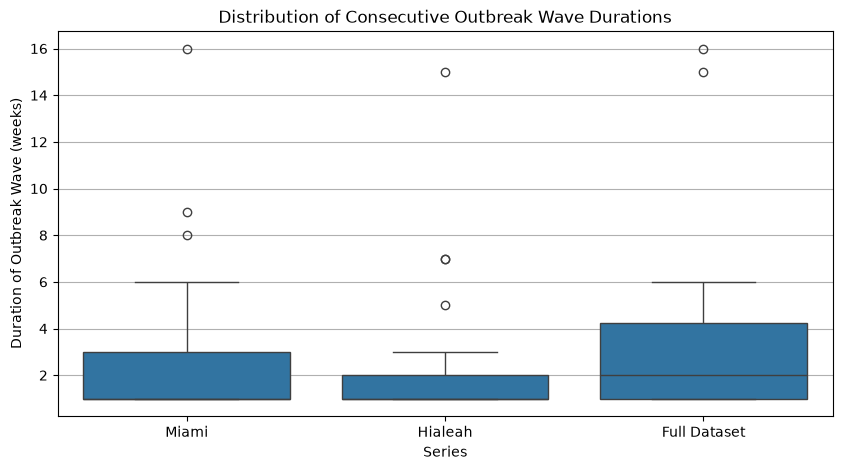

In [31]:
duration_plot_df = pd.concat([
    miami_outbreak_waves.assign(Series="Miami"),
    hialeah_outbreak_waves.assign(Series="Hialeah"),
    full_outbreak_waves.assign(Series="Full Dataset")
])

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=duration_plot_df,
    x="Series",
    y="duration_weeks"
)

plt.title("Distribution of Consecutive Outbreak Wave Durations")
plt.xlabel("Series")
plt.ylabel("Duration of Outbreak Wave (weeks)")
plt.show()

In [32]:
longest_outbreak_waves = (
    duration_plot_df
    .sort_values("duration_weeks", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

longest_outbreak_waves

,start_date,end_date,duration_weeks,peak_count,mean_count,Series
0,2018-02-04,2018-05-20,16,5325,3109.125000,Miami
1,2018-02-04,2018-05-20,16,12604,7123.437500,Full Dataset
2,2021-02-28,2021-06-06,15,1986,941.533333,Hialeah
3,2021-02-28,2021-06-06,15,10065,6324.533333,Full Dataset
4,2020-03-22,2020-05-17,9,6410,3094.888889,Miami
5,2021-02-28,2021-04-18,8,4729,3001.375000,Miami
6,2018-03-04,2018-04-15,7,988,634.142857,Hialeah
7,2021-01-03,2021-02-14,7,844,572.571429,Hialeah
8,2021-01-10,2021-02-14,6,5426,3798.833333,Miami
9,2021-01-10,2021-02-14,6,8935,6991.333333,Full Dataset


In [33]:
def plot_outbreak_waves(ts, outbreak_waves, series_name):
    plt.figure(figsize=(14, 5))

    plt.plot(
        ts.index,
        ts["mosquito_count"],
        label="Mosquito Count"
    )

    for _, row in outbreak_waves.iterrows():
        plt.axvspan(
            row["start_date"],
            row["end_date"],
            alpha=0.2
        )

    plt.title(f"Consecutive Outbreak Waves — {series_name}")
    plt.xlabel("Date")
    plt.ylabel("Mosquito Count")
    plt.legend()
    plt.show()

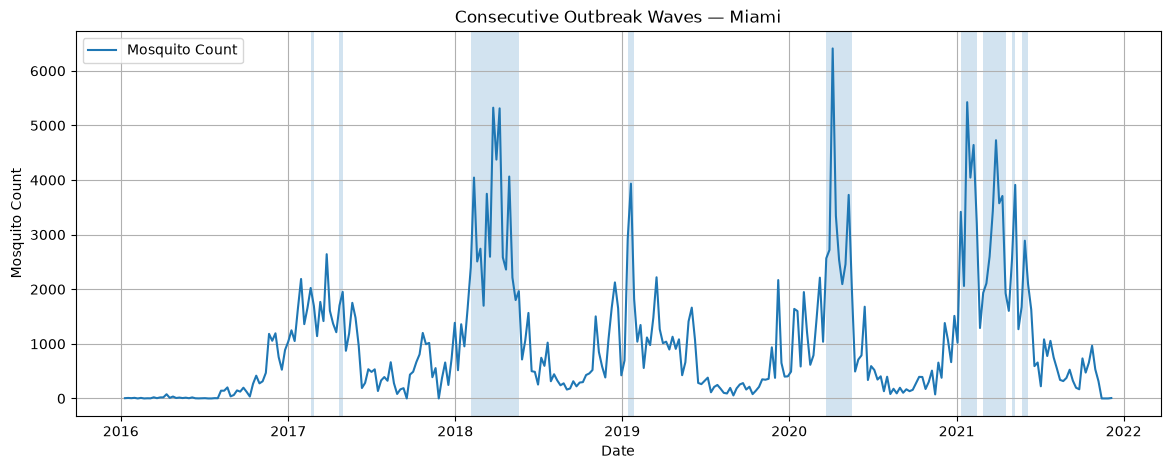

In [34]:
plot_outbreak_waves(
    miami_ts,
    miami_outbreak_waves,
    "Miami"
)

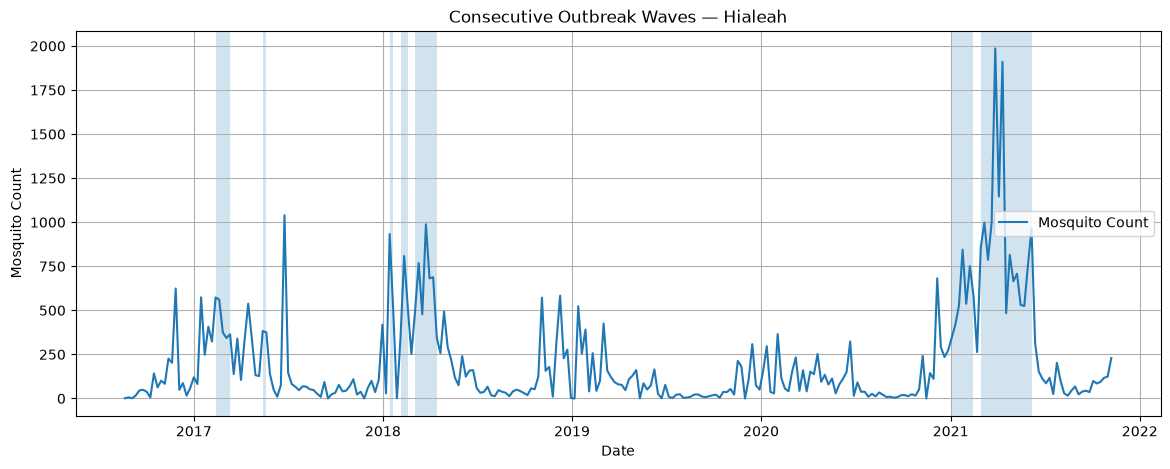

In [35]:
plot_outbreak_waves(
    hialeah_ts,
    hialeah_outbreak_waves,
    "Hialeah"
)

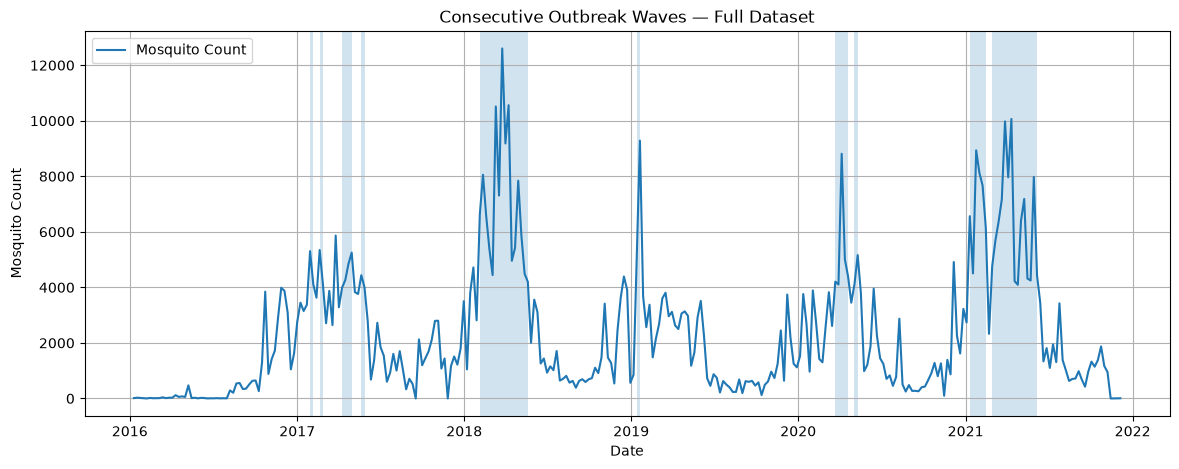

In [36]:
plot_outbreak_waves(
    full_ts,
    full_outbreak_waves,
    "Full Dataset"
)

In [37]:
from scipy.stats import mannwhitneyu, ttest_ind

datasets = {
    'Miami': miami_ts,
    'Hialeah': hialeah_ts,
    'Full Dataset': full_ts
}

results = []
features = ['mosquito_count'] 

for db_name, ts_data in datasets.items():
    outbreak = ts_data[ts_data['outbreak_80'] == 1]
    normal = ts_data[ts_data['outbreak_80'] == 0]
    
    for feat in features:
        if feat in ts_data.columns:
            u_stat, u_p = mannwhitneyu(outbreak[feat], normal[feat], alternative='two-sided')
            t_stat, t_p = ttest_ind(outbreak[feat], normal[feat], equal_var=False, nan_policy='omit')
            
            results.append({
                'Dataset': db_name,
                'Feature': feat,
                'Outbreak Mean': round(outbreak[feat].mean(), 2),
                'Non-Outbreak Mean': round(normal[feat].mean(), 2),
                'Mann-Whitney p-value': u_p,
                'Welch p-value': t_p
            })

results_df = pd.DataFrame(results)
display(results_df)

,Dataset,Feature,Outbreak Mean,Non-Outbreak Mean,Mann-Whitney p-value,Welch p-value
0,Miami,mosquito_count,2837.87,543.01,4.320457e-34,2.331217e-24
1,Hialeah,mosquito_count,659.58,90.38,2.168199e-30,3.339335e-18
2,Full Dataset,mosquito_count,6040.56,1385.72,4.328328e-34,1.140907e-26


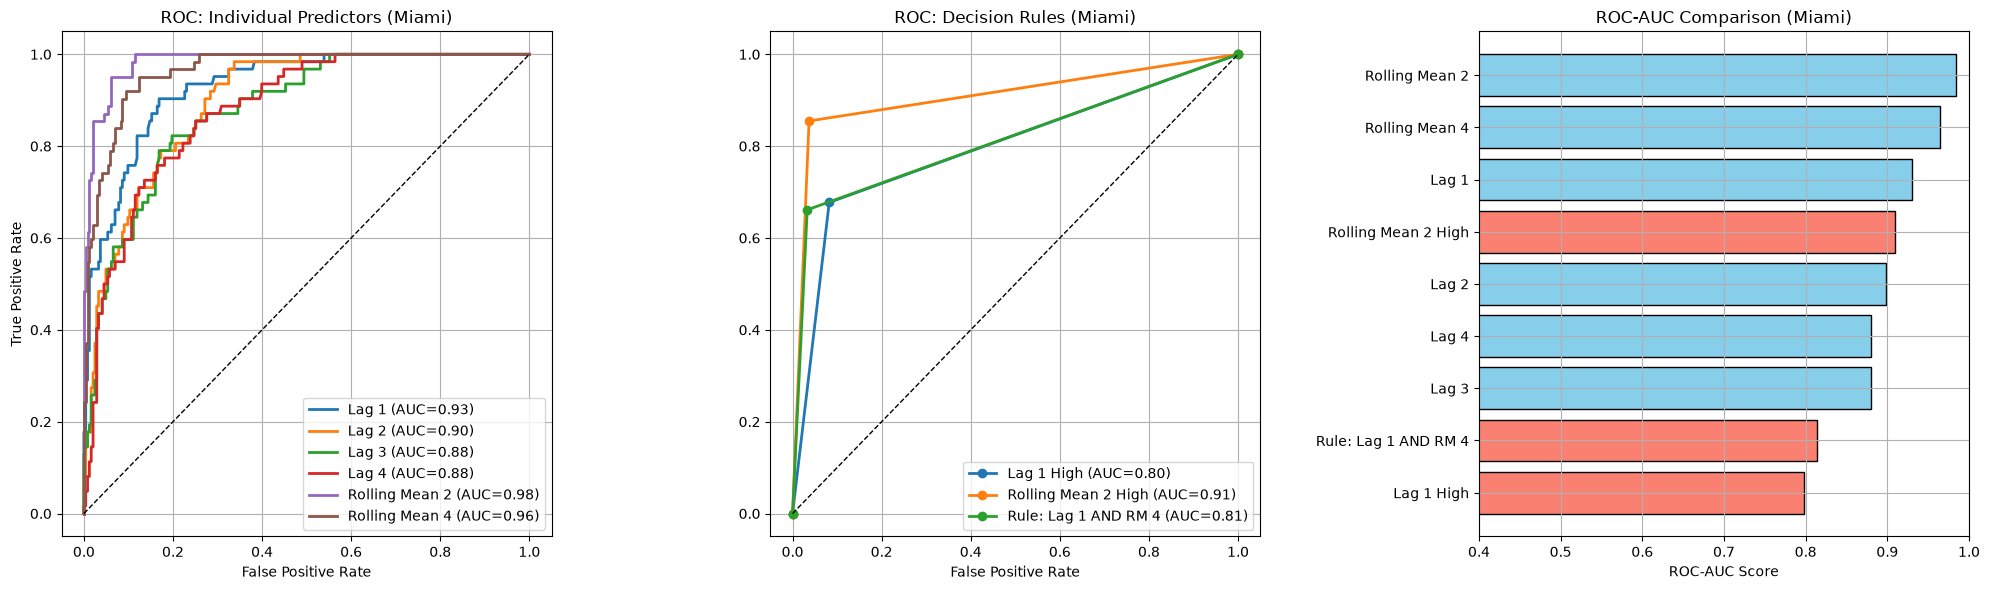

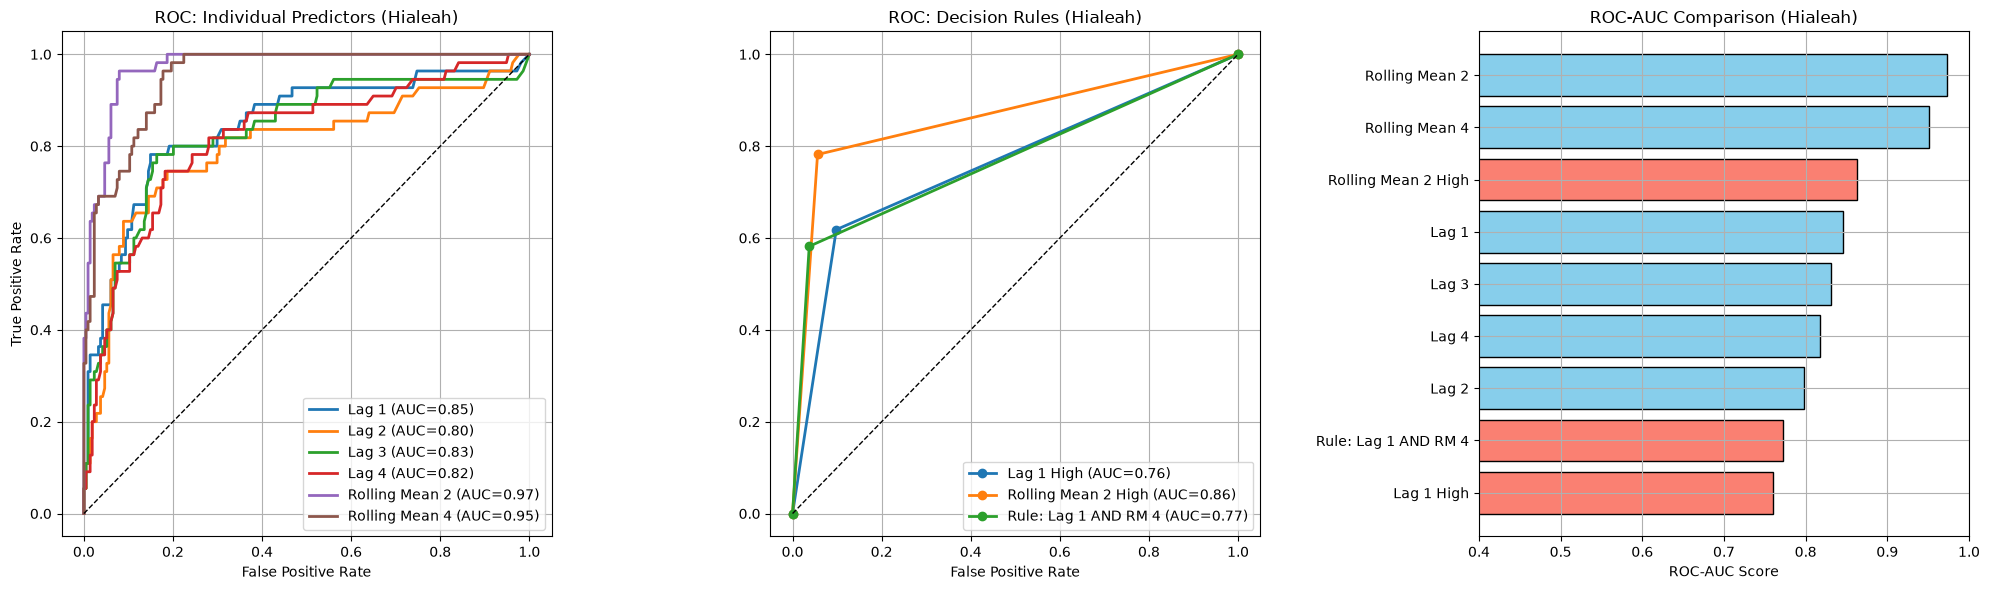

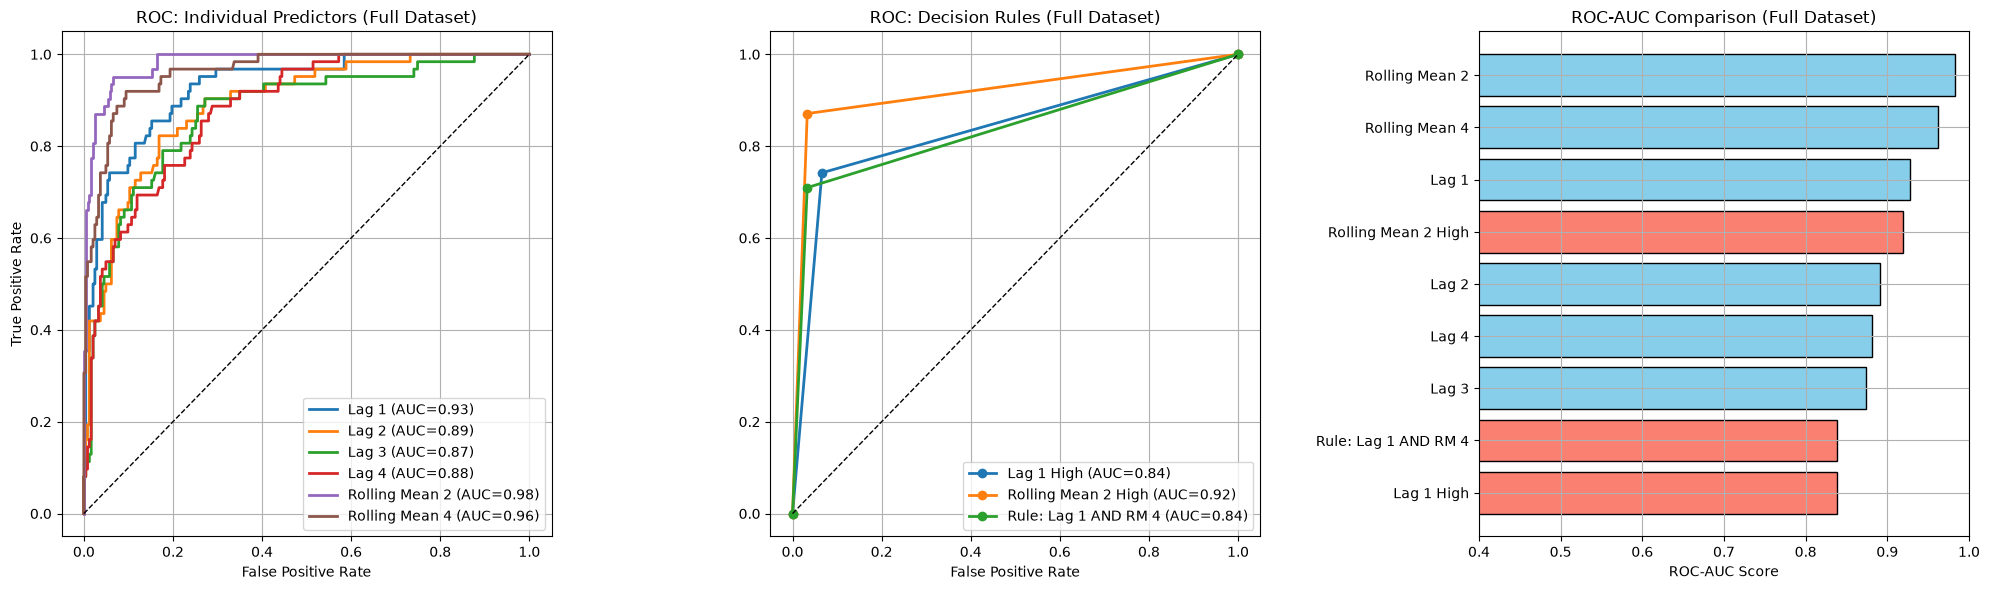

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

def prep_roc_features(df):
    count_col = 'mosquito_count' if 'mosquito_count' in df.columns else 'Cx_quinquefasciatus_fem'
    
    if count_col in df.columns:
        df['Lag 1'] = df[count_col].shift(1)
        df['Lag 2'] = df[count_col].shift(2)
        df['Lag 3'] = df[count_col].shift(3)
        df['Lag 4'] = df[count_col].shift(4)
        df['Rolling Mean 2'] = df[count_col].rolling(window=2, min_periods=1).mean()
        df['Rolling Mean 4'] = df[count_col].rolling(window=4, min_periods=1).mean()
        
        thresh_lag1 = df['Lag 1'].quantile(0.80)
        thresh_rm2 = df['Rolling Mean 2'].quantile(0.80)
        thresh_rm4 = df['Rolling Mean 4'].quantile(0.80)
        
        df['Lag 1 High'] = (df['Lag 1'] >= thresh_lag1).astype(int)
        df['Rolling Mean 2 High'] = (df['Rolling Mean 2'] >= thresh_rm2).astype(int)
        df['Rule: Lag 1 AND RM 4'] = ((df['Lag 1'] >= thresh_lag1) & (df['Rolling Mean 4'] >= thresh_rm4)).astype(int)
    return df

def plot_3_panel_roc(ts_data, city_name):
    ts_data = prep_roc_features(ts_data.copy())
    
    features = ['Lag 1', 'Lag 2', 'Lag 3', 'Lag 4', 'Rolling Mean 2', 'Rolling Mean 4']
    rules = ['Lag 1 High', 'Rolling Mean 2 High', 'Rule: Lag 1 AND RM 4']
    
    if 'outbreak_80' not in ts_data.columns:
        return
        
    test_df = ts_data.dropna(subset=features + rules + ['outbreak_80'])
    
    if test_df.empty:
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    auc_results = []
    
    ax = axes[0]
    for feat in features:
        if feat in test_df.columns:
            fpr, tpr, _ = roc_curve(test_df['outbreak_80'], test_df[feat])
            auc = roc_auc_score(test_df['outbreak_80'], test_df[feat])
            ax.plot(fpr, tpr, label=f'{feat} (AUC={auc:.2f})', lw=2)
            auc_results.append({'Predictor': feat, 'ROC-AUC': auc, 'Type': 'Continuous Feature'})
        
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC: Individual Predictors ({city_name})')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    
    ax = axes[1]
    for rule in rules:
        if rule in test_df.columns:
            fpr, tpr, _ = roc_curve(test_df['outbreak_80'], test_df[rule])
            auc = roc_auc_score(test_df['outbreak_80'], test_df[rule])
            ax.plot(fpr, tpr, marker='o', label=f'{rule} (AUC={auc:.2f})', lw=2)
            auc_results.append({'Predictor': rule, 'ROC-AUC': auc, 'Type': 'Decision Rule'})
        
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC: Decision Rules ({city_name})')
    ax.set_xlabel('False Positive Rate')
    ax.legend(loc='lower right')
    
    ax = axes[2]
    if auc_results:
        results_df = pd.DataFrame(auc_results).sort_values('ROC-AUC', ascending=True)
        colors = ['skyblue' if t == 'Continuous Feature' else 'salmon' for t in results_df['Type']]
        ax.barh(results_df['Predictor'], results_df['ROC-AUC'], color=colors, edgecolor='black')
        ax.set_title(f'ROC-AUC Comparison ({city_name})')
        ax.set_xlabel('ROC-AUC Score')
        ax.set_xlim(0.4, 1.0)
    
    plt.tight_layout(w_pad=4.0)
    plt.show()

datasets_to_plot = {
    "Miami": miami_ts,
    "Hialeah": hialeah_ts,
    "Full Dataset": full_ts
}

for name, data in datasets_to_plot.items():
    try:
        plot_3_panel_roc(data, name)
    except Exception:
        pass

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

def run_logistic_importance(ts_data, features, target='outbreak_80', city_name=''):
    ts_clean = ts_data.copy()
    
    count_col = 'mosquito_count' if 'mosquito_count' in ts_clean.columns else 'Cx_quinquefasciatus_fem'
    
    if count_col in ts_clean.columns:
        ts_clean['Lag 1'] = ts_clean[count_col].shift(1)
        ts_clean['Rolling Mean 2'] = ts_clean[count_col].rolling(window=2, min_periods=1).mean()
        ts_clean['Rolling Mean 4'] = ts_clean[count_col].rolling(window=4, min_periods=1).mean()
    
    if target not in ts_clean.columns:
        print(f"⚠️ SKIPPING {city_name}: Missing '{target}' column.")
        return
    
    ts_clean = ts_clean.dropna(subset=features + [target])
    
    if ts_clean.empty:
        print(f" SKIPPING {city_name}: Dataset is empty after dropping missing values.")
        return
        
    X = ts_clean[features]
    y = ts_clean[target]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = LogisticRegression(random_state=42)
    clf.fit(X_scaled, y)
    
    importance_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': clf.coef_[0],
        'Odds Ratio': np.exp(clf.coef_[0]),
        'Absolute Importance': np.abs(clf.coef_[0])
    }).sort_values(by='Absolute Importance', ascending=False)
    
    display(importance_df)


features_to_test = ['Lag 1', 'Rolling Mean 2', 'Rolling Mean 4']

print("--- Miami Feature Importance ---")
run_logistic_importance(miami_ts, features_to_test, city_name="Miami")

print("\n--- Hialeah Feature Importance ---")
run_logistic_importance(hialeah_ts, features_to_test, city_name="Hialeah")

print("\n--- Full Dataset Feature Importance ---")
run_logistic_importance(full_ts, features_to_test, city_name="Full Dataset")

--- Miami Feature Importance ---


,Feature,Coefficient,Odds Ratio,Absolute Importance
1,Rolling Mean 2,3.923332,50.568642,3.923332
0,Lag 1,-1.548882,0.212485,1.548882
2,Rolling Mean 4,1.126931,3.086171,1.126931



--- Hialeah Feature Importance ---


,Feature,Coefficient,Odds Ratio,Absolute Importance
1,Rolling Mean 2,4.002325,54.725249,4.002325
0,Lag 1,-2.153382,0.116091,2.153382
2,Rolling Mean 4,1.336605,3.806099,1.336605



--- Full Dataset Feature Importance ---


,Feature,Coefficient,Odds Ratio,Absolute Importance
1,Rolling Mean 2,3.730723,41.709251,3.730723
0,Lag 1,-1.442992,0.236220,1.442992
2,Rolling Mean 4,1.298601,3.664166,1.298601


In [40]:
def create_lag_features(ts):
    """
    Creates lagged and rolling mosquito-count features.
    These features use only past mosquito counts.
    """
    df = ts.copy()

    df["lag_1"] = df["mosquito_count"].shift(1)
    df["lag_2"] = df["mosquito_count"].shift(2)
    df["lag_3"] = df["mosquito_count"].shift(3)
    df["lag_4"] = df["mosquito_count"].shift(4)

    df["rolling_mean_2"] = (
        df["mosquito_count"]
        .shift(1)
        .rolling(window=2)
        .mean()
    )

    df["rolling_mean_4"] = (
        df["mosquito_count"]
        .shift(1)
        .rolling(window=4)
        .mean()
    )

    df["growth_rate_1"] = (
        (df["mosquito_count"].shift(1) - df["mosquito_count"].shift(2)) /
        df["mosquito_count"].shift(2).replace(0, np.nan)
    )

    df["growth_rate_1"] = df["growth_rate_1"].replace([np.inf, -np.inf], np.nan)

    return df.dropna()

In [41]:
miami_lag_df = create_lag_features(miami_ts)
hialeah_lag_df = create_lag_features(hialeah_ts)
full_lag_df = create_lag_features(full_ts)

print("Miami lag dataframe:", miami_lag_df.shape)
print("Hialeah lag dataframe:", hialeah_lag_df.shape)
print("Full dataset lag dataframe:", full_lag_df.shape)

Miami lag dataframe: (297, 11)
Hialeah lag dataframe: (264, 11)
Full dataset lag dataframe: (300, 11)


In [42]:
lag_feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_2",
    "rolling_mean_4",
    "growth_rate_1"
]


def pre_outbreak_feature_summary(df, series_name, outbreak_col="outbreak_80"):
    """
    Compares lagged mosquito features for normal weeks vs outbreak weeks.
    """
    results = []

    for feature in lag_feature_cols:
        normal_values = df[df[outbreak_col] == 0][feature]
        outbreak_values = df[df[outbreak_col] == 1][feature]

        results.append({
            "Series": series_name,
            "Feature": feature,
            "Normal Mean": normal_values.mean(),
            "Outbreak Mean": outbreak_values.mean(),
            "Difference": outbreak_values.mean() - normal_values.mean(),
            "Normal Median": normal_values.median(),
            "Outbreak Median": outbreak_values.median(),
            "Outbreak / Normal Mean Ratio": (
                outbreak_values.mean() / normal_values.mean()
                if normal_values.mean() != 0 else np.nan
            )
        })

    return pd.DataFrame(results)

In [43]:
miami_pre_outbreak_summary = pre_outbreak_feature_summary(
    miami_lag_df,
    series_name="Miami",
    outbreak_col="outbreak_80"
)

miami_pre_outbreak_summary

,Series,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Outbreak / Normal Mean Ratio
0,Miami,lag_1,645.144681,2542.129032,1896.984351,424.000000,2383.000000,3.940401
1,Miami,lag_2,696.034043,2362.629032,1666.594990,426.000000,2100.500000,3.394416
2,Miami,lag_3,701.063830,2326.209677,1625.145848,436.000000,2077.000000,3.318114
3,Miami,lag_4,716.582979,2262.145161,1545.562183,426.000000,2083.500000,3.156850
4,Miami,rolling_mean_2,670.589362,2452.379032,1781.789671,453.000000,2261.000000,3.657050
5,Miami,rolling_mean_4,689.706383,2373.278226,1683.571843,490.500000,2393.875000,3.440998
6,Miami,growth_rate_1,0.434164,0.269864,-0.164300,0.024169,0.194254,0.621572


In [44]:
hialeah_pre_outbreak_summary = pre_outbreak_feature_summary(
    hialeah_lag_df,
    series_name="Hialeah",
    outbreak_col="outbreak_80"
)

hialeah_pre_outbreak_summary

,Series,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Outbreak / Normal Mean Ratio
0,Hialeah,lag_1,126.157895,518.436364,392.278469,67.000000,478.000000,4.109425
1,Hialeah,lag_2,138.736842,484.054545,345.317703,75.000000,478.000000,3.489012
2,Hialeah,lag_3,130.291866,504.036364,373.744498,67.000000,419.000000,3.868517
3,Hialeah,lag_4,135.038278,484.000000,348.961722,67.000000,419.000000,3.584169
4,Hialeah,rolling_mean_2,132.447368,501.245455,368.798086,80.500000,448.000000,3.784488
5,Hialeah,rolling_mean_4,132.556220,497.631818,365.075598,89.250000,462.750000,3.754119
6,Hialeah,growth_rate_1,1.521869,7.749483,6.227614,-0.070175,0.064662,5.092083


In [45]:
full_pre_outbreak_summary = pre_outbreak_feature_summary(
    full_lag_df,
    series_name="Full Dataset",
    outbreak_col="outbreak_80"
)

full_pre_outbreak_summary

,Series,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Outbreak / Normal Mean Ratio
0,Full Dataset,lag_1,1568.495798,5485.677419,3917.181621,1112.500000,4904.000000,3.497413
1,Full Dataset,lag_2,1660.210084,5187.241935,3527.031851,1159.000000,4416.000000,3.124449
2,Full Dataset,lag_3,1679.743697,5065.435484,3385.691786,1159.000000,4472.500000,3.015600
3,Full Dataset,lag_4,1677.878151,5056.806452,3378.928300,1131.500000,4610.500000,3.013810
4,Full Dataset,rolling_mean_2,1614.352941,5336.459677,3722.106736,1259.750000,4813.500000,3.305634
5,Full Dataset,rolling_mean_4,1646.581933,5198.790323,3552.208390,1340.250000,5320.750000,3.157323
6,Full Dataset,growth_rate_1,0.595726,0.270122,-0.325604,0.001074,0.106888,0.453433


In [46]:
combined_pre_outbreak_summary = pd.concat([
    miami_pre_outbreak_summary,
    hialeah_pre_outbreak_summary,
    full_pre_outbreak_summary
]).reset_index(drop=True)

combined_pre_outbreak_summary

,Series,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Outbreak / Normal Mean Ratio
0,Miami,lag_1,645.144681,2542.129032,1896.984351,424.000000,2383.000000,3.940401
1,Miami,lag_2,696.034043,2362.629032,1666.594990,426.000000,2100.500000,3.394416
2,Miami,lag_3,701.063830,2326.209677,1625.145848,436.000000,2077.000000,3.318114
3,Miami,lag_4,716.582979,2262.145161,1545.562183,426.000000,2083.500000,3.156850
4,Miami,rolling_mean_2,670.589362,2452.379032,1781.789671,453.000000,2261.000000,3.657050
5,Miami,rolling_mean_4,689.706383,2373.278226,1683.571843,490.500000,2393.875000,3.440998
6,Miami,growth_rate_1,0.434164,0.269864,-0.164300,0.024169,0.194254,0.621572
7,Hialeah,lag_1,126.157895,518.436364,392.278469,67.000000,478.000000,4.109425
8,Hialeah,lag_2,138.736842,484.054545,345.317703,75.000000,478.000000,3.489012
9,Hialeah,lag_3,130.291866,504.036364,373.744498,67.000000,419.000000,3.868517


In [47]:
combined_pre_outbreak_summary.style.format({
    "Normal Mean": "{:.2f}",
    "Outbreak Mean": "{:.2f}",
    "Difference": "{:.2f}",
    "Normal Median": "{:.2f}",
    "Outbreak Median": "{:.2f}",
    "Outbreak / Normal Mean Ratio": "{:.2f}"
})

,Series,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Outbreak / Normal Mean Ratio
0,Miami,lag_1,645.14,2542.13,1896.98,424.00,2383.00,3.94
1,Miami,lag_2,696.03,2362.63,1666.59,426.00,2100.50,3.39
2,Miami,lag_3,701.06,2326.21,1625.15,436.00,2077.00,3.32
3,Miami,lag_4,716.58,2262.15,1545.56,426.00,2083.50,3.16
4,Miami,rolling_mean_2,670.59,2452.38,1781.79,453.00,2261.00,3.66
5,Miami,rolling_mean_4,689.71,2373.28,1683.57,490.50,2393.88,3.44
6,Miami,growth_rate_1,0.43,0.27,-0.16,0.02,0.19,0.62
7,Hialeah,lag_1,126.16,518.44,392.28,67.00,478.00,4.11
8,Hialeah,lag_2,138.74,484.05,345.32,75.00,478.00,3.49
9,Hialeah,lag_3,130.29,504.04,373.74,67.00,419.00,3.87


In [48]:
def plot_lag_feature_boxplots(df, series_name, outbreak_col="outbreak_80"):
    """
    Creates boxplots comparing lag features for normal vs outbreak weeks.
    """
    plot_df = df.copy()
    plot_df["Outbreak Status"] = plot_df[outbreak_col].map({
        0: "Normal Week",
        1: "Outbreak Week"
    })

    for feature in lag_feature_cols:
        plt.figure(figsize=(8, 5))

        sns.boxplot(
            data=plot_df,
            x="Outbreak Status",
            y=feature
        )

        plt.title(f"{feature} Before Normal vs Outbreak Weeks — {series_name}")
        plt.xlabel("")
        plt.ylabel(feature)
        plt.show()

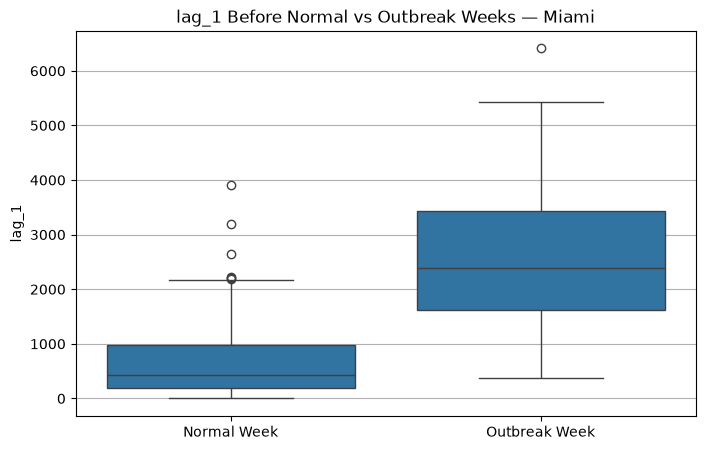

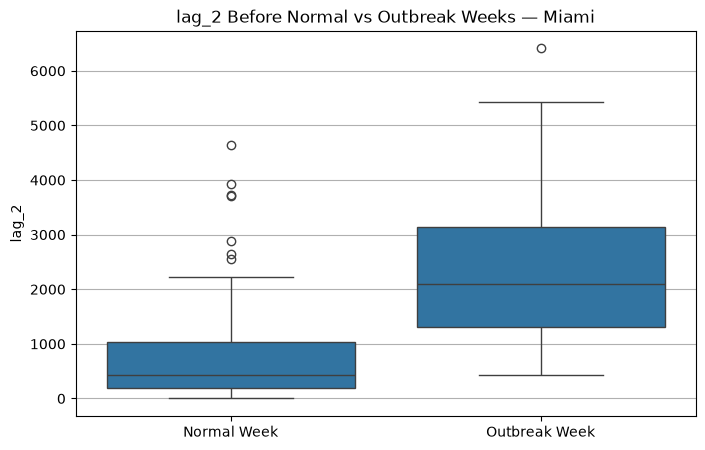

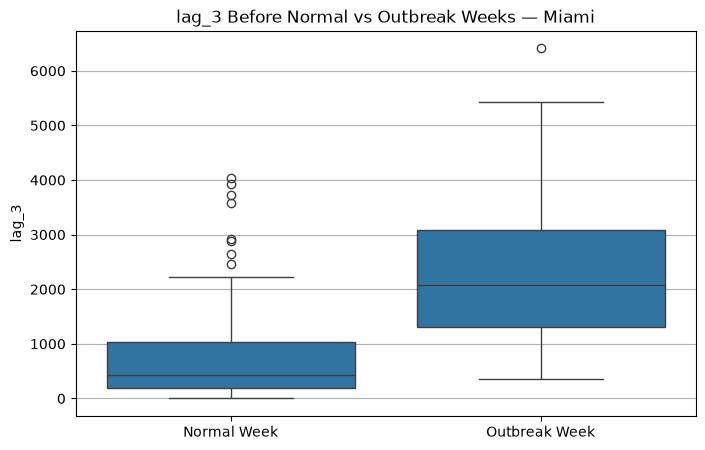

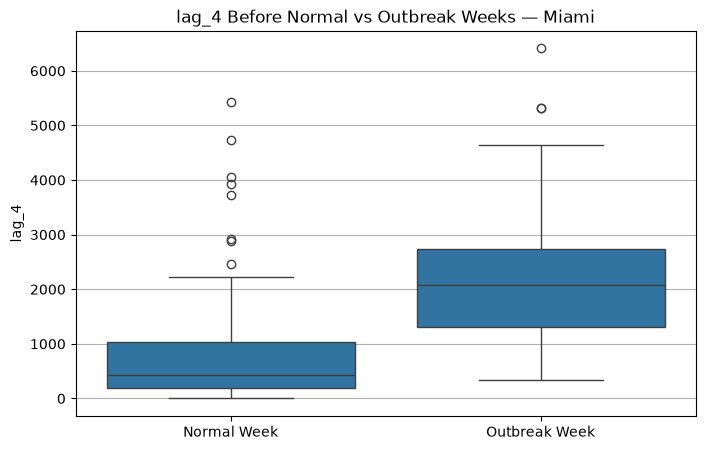

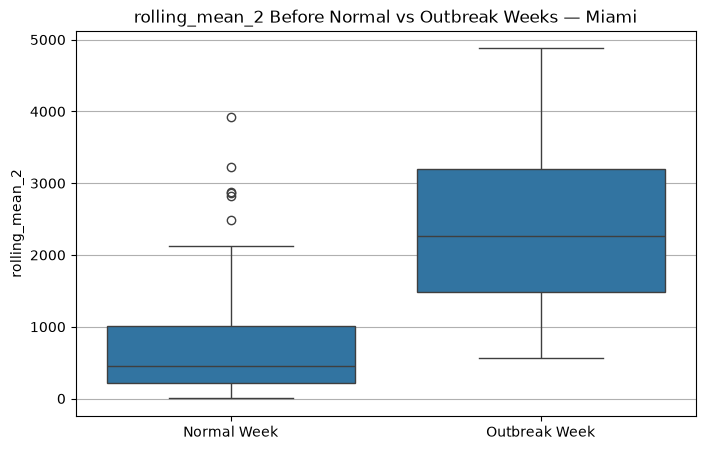

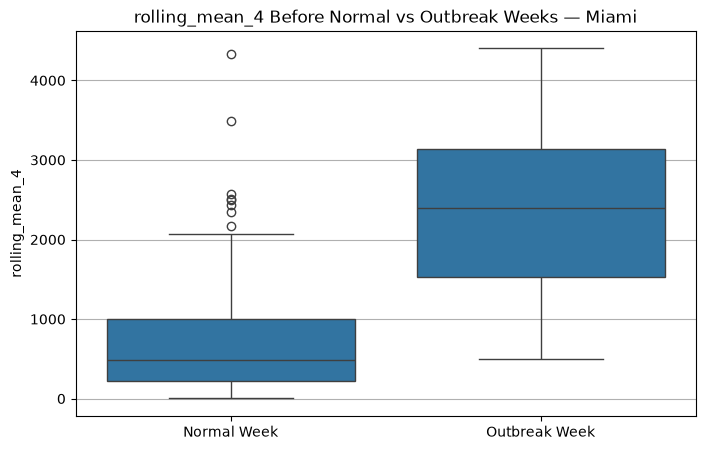

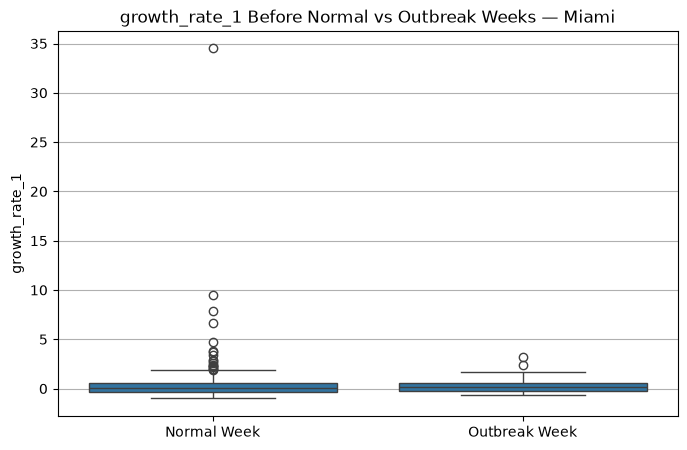

In [49]:
plot_lag_feature_boxplots(
    miami_lag_df,
    series_name="Miami",
    outbreak_col="outbreak_80"
)

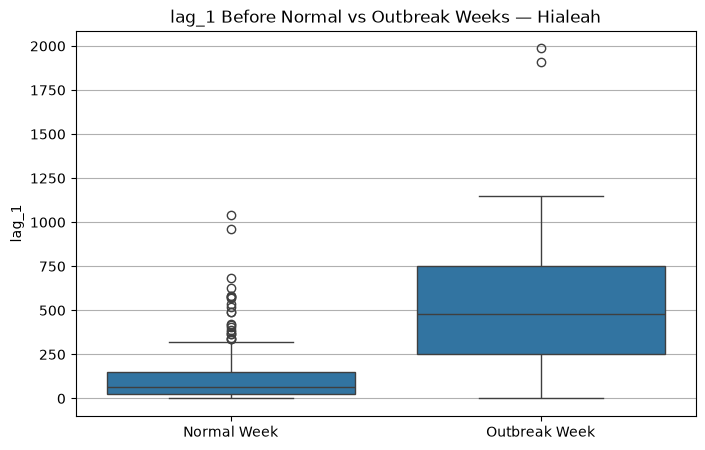

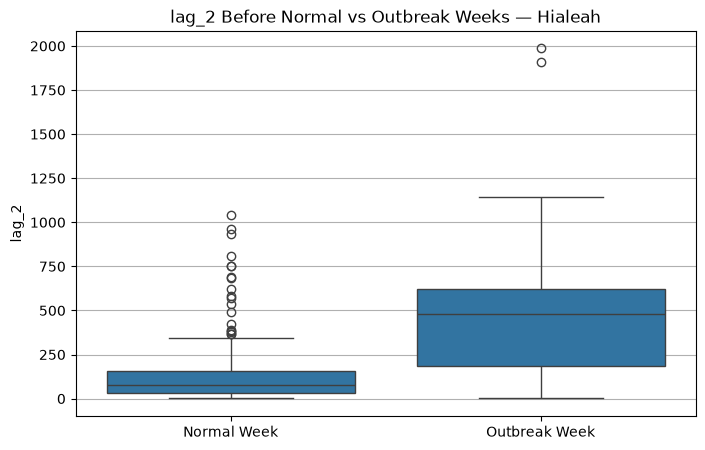

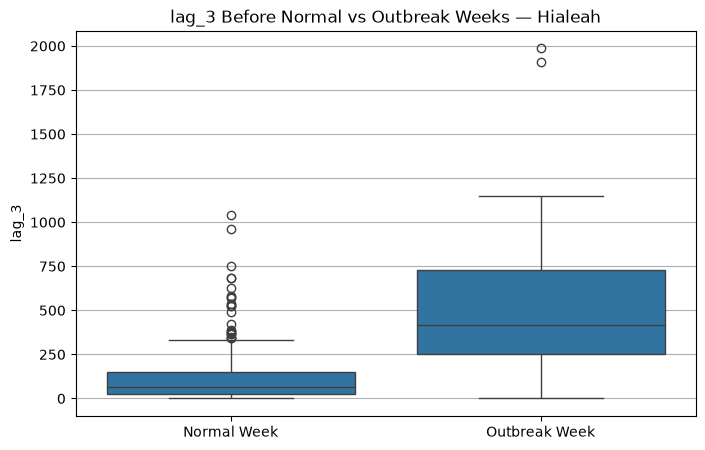

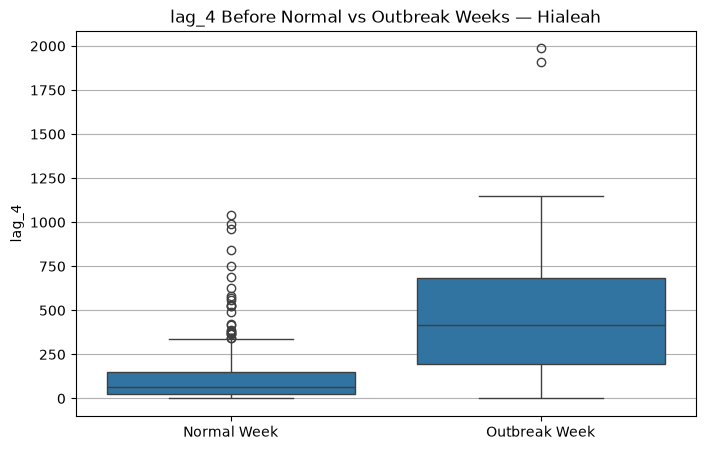

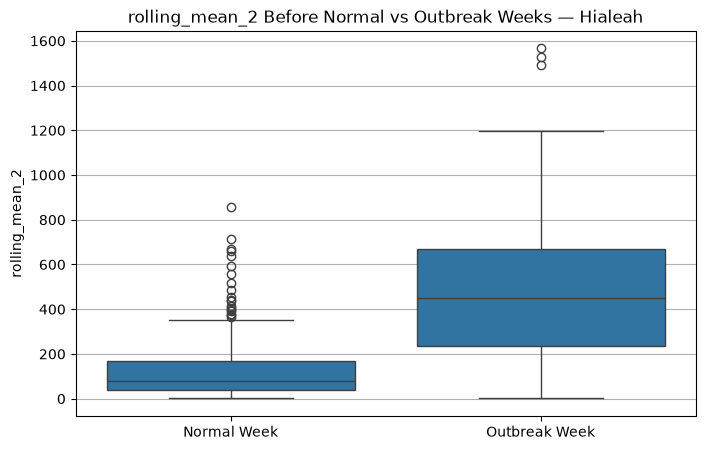

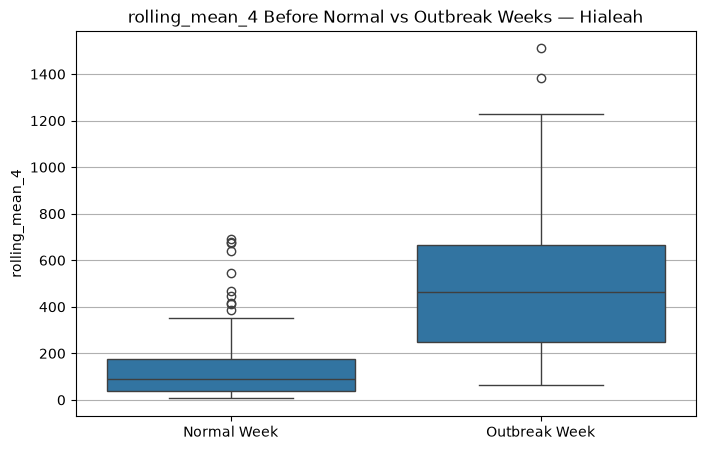

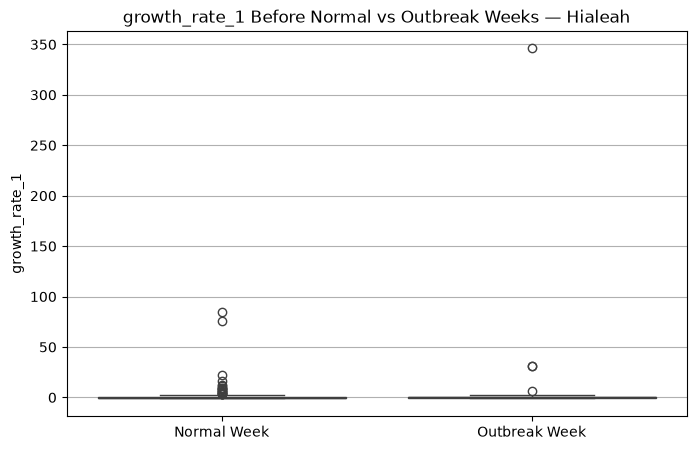

In [50]:
plot_lag_feature_boxplots(
    hialeah_lag_df,
    series_name="Hialeah",
    outbreak_col="outbreak_80"
)

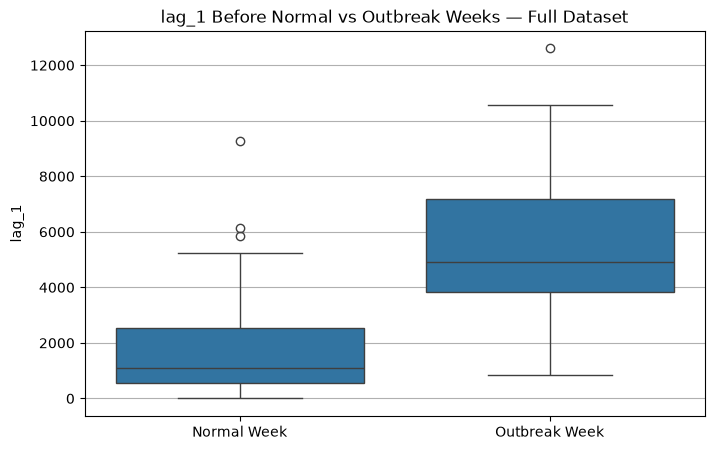

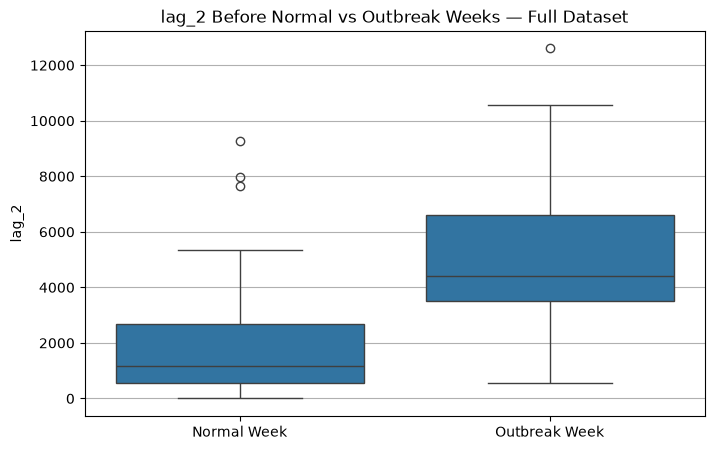

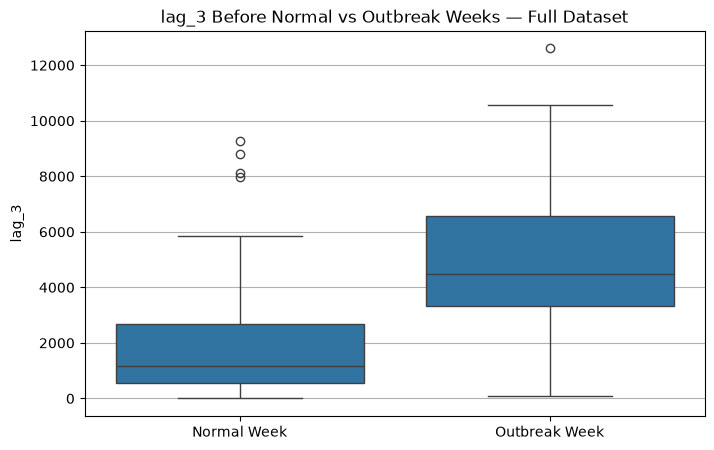

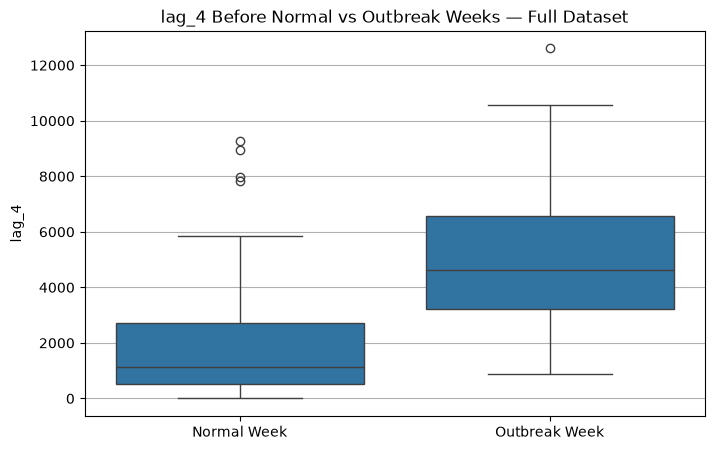

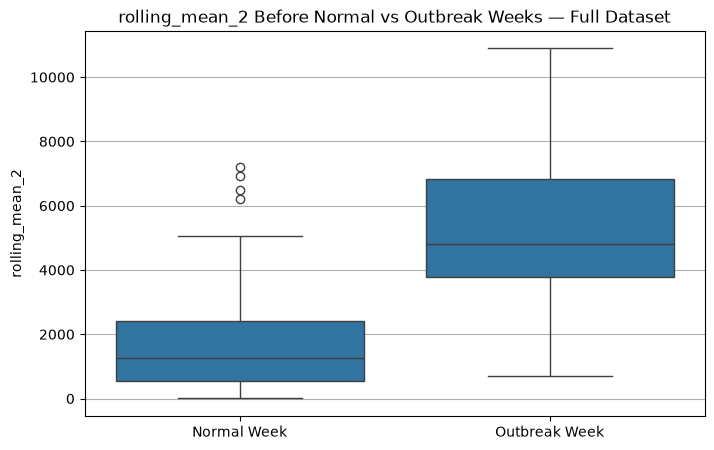

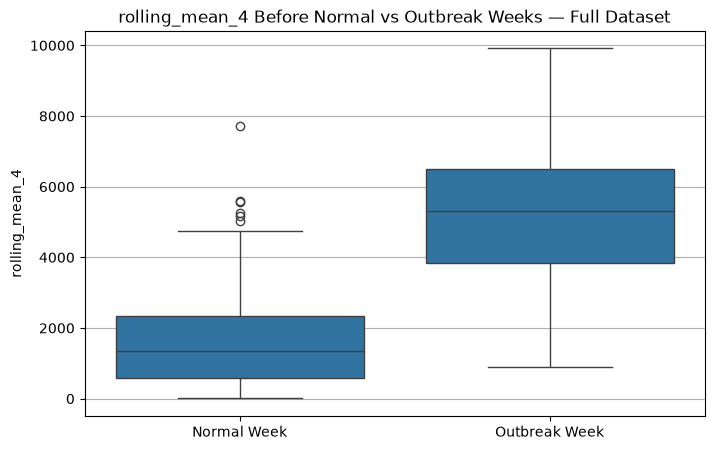

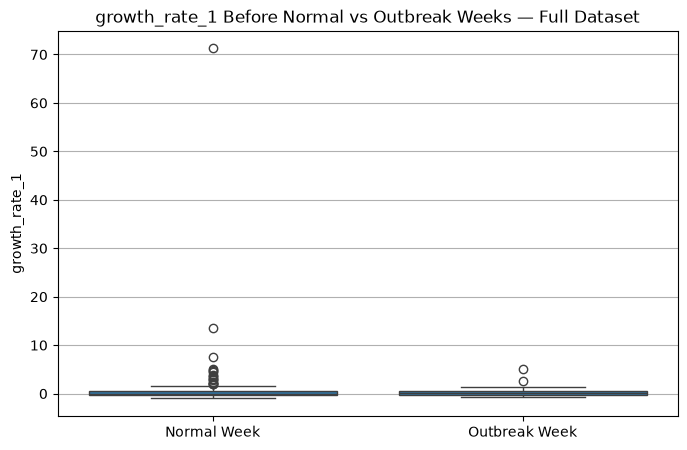

In [51]:
plot_lag_feature_boxplots(
    full_lag_df,
    series_name="Full Dataset",
    outbreak_col="outbreak_80"
)

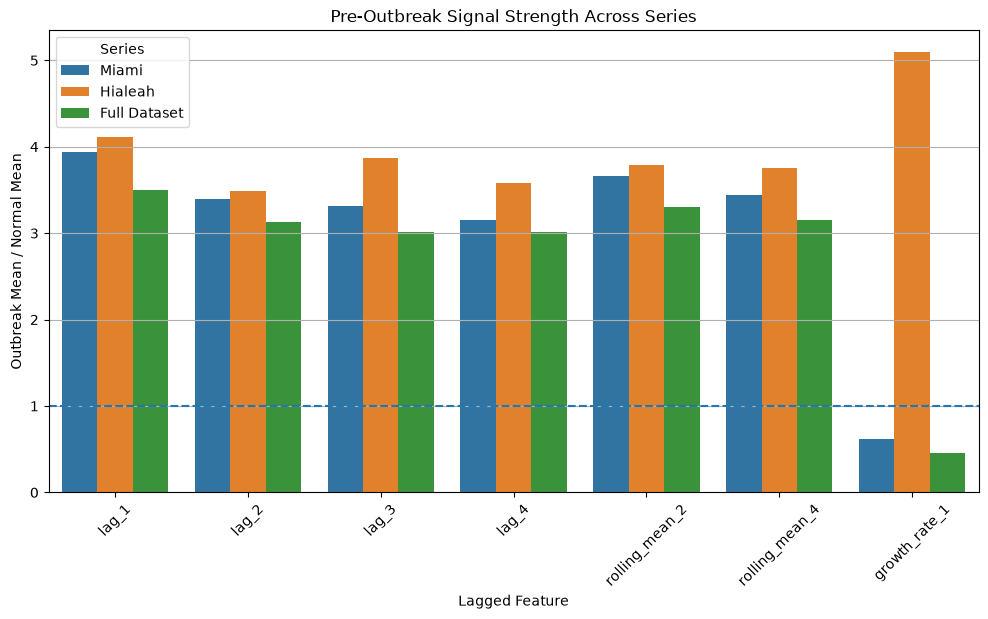

In [52]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined_pre_outbreak_summary,
    x="Feature",
    y="Outbreak / Normal Mean Ratio",
    hue="Series"
)

plt.axhline(1, linestyle="--")

plt.title("Pre-Outbreak Signal Strength Across Series")
plt.xlabel("Lagged Feature")
plt.ylabel("Outbreak Mean / Normal Mean")
plt.xticks(rotation=45)
plt.legend(title="Series")
plt.show()

In [53]:
def lag_outbreak_correlations(df, series_name, outbreak_col="outbreak_80"):
    """
    Computes correlation between lagged mosquito features and outbreak status.
    """
    results = []

    for feature in lag_feature_cols:
        corr = df[[feature, outbreak_col]].corr().iloc[0, 1]

        results.append({
            "Series": series_name,
            "Feature": feature,
            "Correlation with Outbreak": corr
        })

    return pd.DataFrame(results)

In [54]:
miami_corr = lag_outbreak_correlations(miami_lag_df, "Miami")
hialeah_corr = lag_outbreak_correlations(hialeah_lag_df, "Hialeah")
full_corr = lag_outbreak_correlations(full_lag_df, "Full Dataset")

combined_corr = pd.concat([
    miami_corr,
    hialeah_corr,
    full_corr
]).reset_index(drop=True)

combined_corr

,Series,Feature,Correlation with Outbreak
0,Miami,lag_1,0.681016
1,Miami,lag_2,0.599412
2,Miami,lag_3,0.583123
3,Miami,lag_4,0.554162
4,Miami,rolling_mean_2,0.681222
5,Miami,rolling_mean_4,0.683574
6,Miami,growth_rate_1,-0.028988
7,Hialeah,lag_1,0.560097
8,Hialeah,lag_2,0.493206
9,Hialeah,lag_3,0.531764


In [55]:
combined_corr.style.format({
    "Correlation with Outbreak": "{:.3f}"
})

,Series,Feature,Correlation with Outbreak
0,Miami,lag_1,0.681
1,Miami,lag_2,0.599
2,Miami,lag_3,0.583
3,Miami,lag_4,0.554
4,Miami,rolling_mean_2,0.681
5,Miami,rolling_mean_4,0.684
6,Miami,growth_rate_1,-0.029
7,Hialeah,lag_1,0.560
8,Hialeah,lag_2,0.493
9,Hialeah,lag_3,0.532


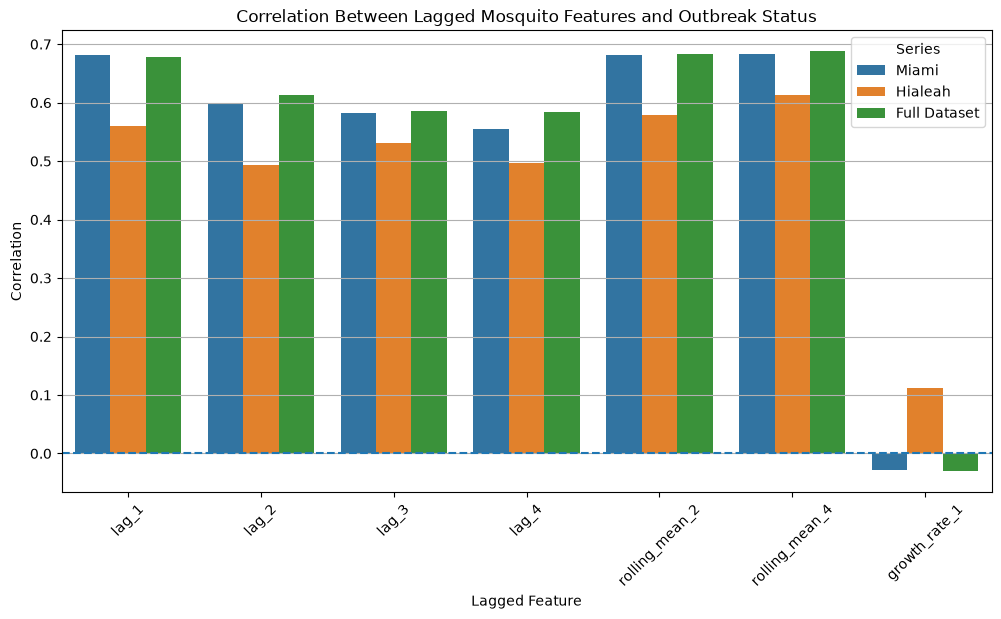

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined_corr,
    x="Feature",
    y="Correlation with Outbreak",
    hue="Series"
)

plt.axhline(0, linestyle="--")

plt.title("Correlation Between Lagged Mosquito Features and Outbreak Status")
plt.xlabel("Lagged Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.legend(title="Series")
plt.show()

In [57]:
top_warning_features = (
    combined_corr
    .sort_values(["Series", "Correlation with Outbreak"], ascending=[True, False])
    .groupby("Series")
    .head(3)
    .reset_index(drop=True)
)

top_warning_features

,Series,Feature,Correlation with Outbreak
0,Full Dataset,rolling_mean_4,0.687665
1,Full Dataset,rolling_mean_2,0.683494
2,Full Dataset,lag_1,0.678566
3,Hialeah,rolling_mean_4,0.612269
4,Hialeah,rolling_mean_2,0.578953
5,Hialeah,lag_1,0.560097
6,Miami,rolling_mean_4,0.683574
7,Miami,rolling_mean_2,0.681222
8,Miami,lag_1,0.681016


In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

In [59]:
def evaluate_decision_rule(y_true, y_pred, rule_name, series_name):
    """
    Evaluates a binary outbreak decision rule.
    """
    return {
        "Series": series_name,
        "Rule": rule_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Predicted Outbreak Weeks": int(np.sum(y_pred)),
        "Actual Outbreak Weeks": int(np.sum(y_true))
    }

In [60]:
def apply_univariate_rules(df, series_name, outbreak_col="outbreak_80"):
    """
    Applies several rule-based outbreak detectors using only
    lagged mosquito-count features.
    """
    df = df.copy()

    y_true = df[outbreak_col].values

    # Feature-specific high thresholds
    lag1_threshold = df["lag_1"].quantile(0.75)
    lag2_threshold = df["lag_2"].quantile(0.75)
    rolling2_threshold = df["rolling_mean_2"].quantile(0.75)
    rolling4_threshold = df["rolling_mean_4"].quantile(0.75)
    growth_threshold = df["growth_rate_1"].quantile(0.75)

    rules = {}

    # Single-feature rules
    rules["Lag 1 High"] = (df["lag_1"] >= lag1_threshold).astype(int)

    rules["Lag 2 High"] = (df["lag_2"] >= lag2_threshold).astype(int)

    rules["Rolling Mean 2 High"] = (
        df["rolling_mean_2"] >= rolling2_threshold
    ).astype(int)

    rules["Rolling Mean 4 High"] = (
        df["rolling_mean_4"] >= rolling4_threshold
    ).astype(int)

    rules["Growth Rate High"] = (
        df["growth_rate_1"] >= growth_threshold
    ).astype(int)

    # Combined AND rules: stricter, usually higher precision
    rules["Lag 1 High AND Rolling Mean 4 High"] = (
        (df["lag_1"] >= lag1_threshold) &
        (df["rolling_mean_4"] >= rolling4_threshold)
    ).astype(int)

    rules["Rolling Mean 2 High AND Rolling Mean 4 High"] = (
        (df["rolling_mean_2"] >= rolling2_threshold) &
        (df["rolling_mean_4"] >= rolling4_threshold)
    ).astype(int)

    # OR rule: more sensitive, usually higher recall
    rules["Lag 1 High OR Rolling Mean 4 High"] = (
        (df["lag_1"] >= lag1_threshold) |
        (df["rolling_mean_4"] >= rolling4_threshold)
    ).astype(int)

    results = []

    predictions = {}

    for rule_name, y_pred in rules.items():
        results.append(
            evaluate_decision_rule(
                y_true=y_true,
                y_pred=y_pred.values,
                rule_name=rule_name,
                series_name=series_name
            )
        )

        predictions[rule_name] = y_pred.values

    results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)

    thresholds = {
        "lag_1_threshold": lag1_threshold,
        "lag_2_threshold": lag2_threshold,
        "rolling_mean_2_threshold": rolling2_threshold,
        "rolling_mean_4_threshold": rolling4_threshold,
        "growth_rate_1_threshold": growth_threshold
    }

    return results_df, predictions, thresholds

In [61]:
miami_rule_results, miami_rule_predictions, miami_rule_thresholds = apply_univariate_rules(
    miami_lag_df,
    series_name="Miami",
    outbreak_col="outbreak_80"
)

miami_rule_results

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Miami,Rolling Mean 2 High AND Rolling Mean 4 High,0.878788,0.696970,0.741935,0.718750,66,62
1,Miami,Lag 1 High AND Rolling Mean 4 High,0.882155,0.728814,0.693548,0.710744,59,62
2,Miami,Rolling Mean 4 High,0.861953,0.640000,0.774194,0.700730,75,62
3,Miami,Rolling Mean 2 High,0.861953,0.640000,0.774194,0.700730,75,62
4,Miami,Lag 1 High,0.855219,0.626667,0.758065,0.686131,75,62
5,Miami,Lag 1 High OR Rolling Mean 4 High,0.835017,0.571429,0.838710,0.679739,91,62
6,Miami,Lag 2 High,0.835017,0.586667,0.709677,0.642336,75,62
7,Miami,Growth Rate High,0.646465,0.213333,0.258065,0.233577,75,62


In [62]:
hialeah_rule_results, hialeah_rule_predictions, hialeah_rule_thresholds = apply_univariate_rules(
    hialeah_lag_df,
    series_name="Hialeah",
    outbreak_col="outbreak_80"
)

hialeah_rule_results

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Rolling Mean 2 High AND Rolling Mean 4 High,0.856061,0.660377,0.636364,0.648148,53,55
1,Hialeah,Lag 1 High AND Rolling Mean 4 High,0.852273,0.660000,0.600000,0.628571,50,55
2,Hialeah,Rolling Mean 4 High,0.829545,0.575758,0.690909,0.628099,66,55
3,Hialeah,Rolling Mean 2 High,0.825758,0.567164,0.690909,0.622951,67,55
4,Hialeah,Lag 1 High OR Rolling Mean 4 High,0.799242,0.512195,0.763636,0.613139,82,55
5,Hialeah,Lag 1 High,0.821970,0.560606,0.672727,0.611570,66,55
6,Hialeah,Lag 2 High,0.814394,0.545455,0.654545,0.595041,66,55
7,Hialeah,Growth Rate High,0.647727,0.212121,0.254545,0.231405,66,55


In [63]:
full_rule_results, full_rule_predictions, full_rule_thresholds = apply_univariate_rules(
    full_lag_df,
    series_name="Full Dataset",
    outbreak_col="outbreak_80"
)

full_rule_results

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Full Dataset,Rolling Mean 2 High AND Rolling Mean 4 High,0.896667,0.731343,0.790323,0.759690,67,62
1,Full Dataset,Rolling Mean 2 High,0.883333,0.680000,0.822581,0.744526,75,62
2,Full Dataset,Lag 1 High AND Rolling Mean 4 High,0.893333,0.750000,0.725806,0.737705,60,62
3,Full Dataset,Rolling Mean 4 High,0.870000,0.653333,0.790323,0.715328,75,62
4,Full Dataset,Lag 1 High,0.863333,0.640000,0.774194,0.700730,75,62
5,Full Dataset,Lag 1 High OR Rolling Mean 4 High,0.840000,0.577778,0.838710,0.684211,90,62
6,Full Dataset,Lag 2 High,0.843333,0.600000,0.725806,0.656934,75,62
7,Full Dataset,Growth Rate High,0.656667,0.226667,0.274194,0.248175,75,62


In [64]:
combined_rule_results = pd.concat([
    miami_rule_results,
    hialeah_rule_results,
    full_rule_results
]).reset_index(drop=True)

combined_rule_results = combined_rule_results.sort_values(
    ["Series", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

combined_rule_results

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Full Dataset,Rolling Mean 2 High AND Rolling Mean 4 High,0.896667,0.731343,0.790323,0.759690,67,62
1,Full Dataset,Rolling Mean 2 High,0.883333,0.680000,0.822581,0.744526,75,62
2,Full Dataset,Lag 1 High AND Rolling Mean 4 High,0.893333,0.750000,0.725806,0.737705,60,62
3,Full Dataset,Rolling Mean 4 High,0.870000,0.653333,0.790323,0.715328,75,62
4,Full Dataset,Lag 1 High,0.863333,0.640000,0.774194,0.700730,75,62
5,Full Dataset,Lag 1 High OR Rolling Mean 4 High,0.840000,0.577778,0.838710,0.684211,90,62
6,Full Dataset,Lag 2 High,0.843333,0.600000,0.725806,0.656934,75,62
7,Full Dataset,Growth Rate High,0.656667,0.226667,0.274194,0.248175,75,62
8,Hialeah,Rolling Mean 2 High AND Rolling Mean 4 High,0.856061,0.660377,0.636364,0.648148,53,55
9,Hialeah,Lag 1 High AND Rolling Mean 4 High,0.852273,0.660000,0.600000,0.628571,50,55


In [65]:
combined_rule_results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Full Dataset,Rolling Mean 2 High AND Rolling Mean 4 High,0.897,0.731,0.790,0.760,67,62
1,Full Dataset,Rolling Mean 2 High,0.883,0.680,0.823,0.745,75,62
2,Full Dataset,Lag 1 High AND Rolling Mean 4 High,0.893,0.750,0.726,0.738,60,62
3,Full Dataset,Rolling Mean 4 High,0.870,0.653,0.790,0.715,75,62
4,Full Dataset,Lag 1 High,0.863,0.640,0.774,0.701,75,62
5,Full Dataset,Lag 1 High OR Rolling Mean 4 High,0.840,0.578,0.839,0.684,90,62
6,Full Dataset,Lag 2 High,0.843,0.600,0.726,0.657,75,62
7,Full Dataset,Growth Rate High,0.657,0.227,0.274,0.248,75,62
8,Hialeah,Rolling Mean 2 High AND Rolling Mean 4 High,0.856,0.660,0.636,0.648,53,55
9,Hialeah,Lag 1 High AND Rolling Mean 4 High,0.852,0.660,0.600,0.629,50,55


In [66]:
best_rules_by_series = (
    combined_rule_results
    .sort_values(["Series", "F1"], ascending=[True, False])
    .groupby("Series")
    .head(1)
    .reset_index(drop=True)
)

best_rules_by_series

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Full Dataset,Rolling Mean 2 High AND Rolling Mean 4 High,0.896667,0.731343,0.790323,0.759690,67,62
1,Hialeah,Rolling Mean 2 High AND Rolling Mean 4 High,0.856061,0.660377,0.636364,0.648148,53,55
2,Miami,Rolling Mean 2 High AND Rolling Mean 4 High,0.878788,0.696970,0.741935,0.718750,66,62


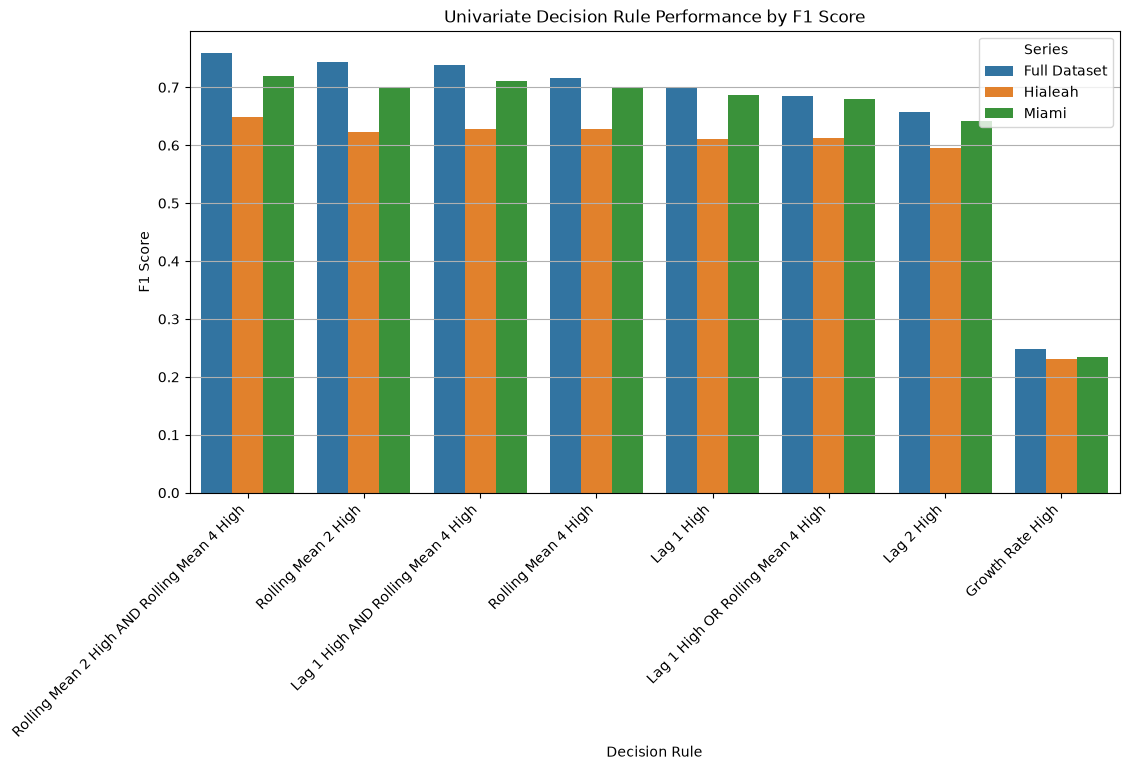

In [67]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined_rule_results,
    x="Rule",
    y="F1",
    hue="Series"
)

plt.title("Univariate Decision Rule Performance by F1 Score")
plt.xlabel("Decision Rule")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Series")
plt.show()

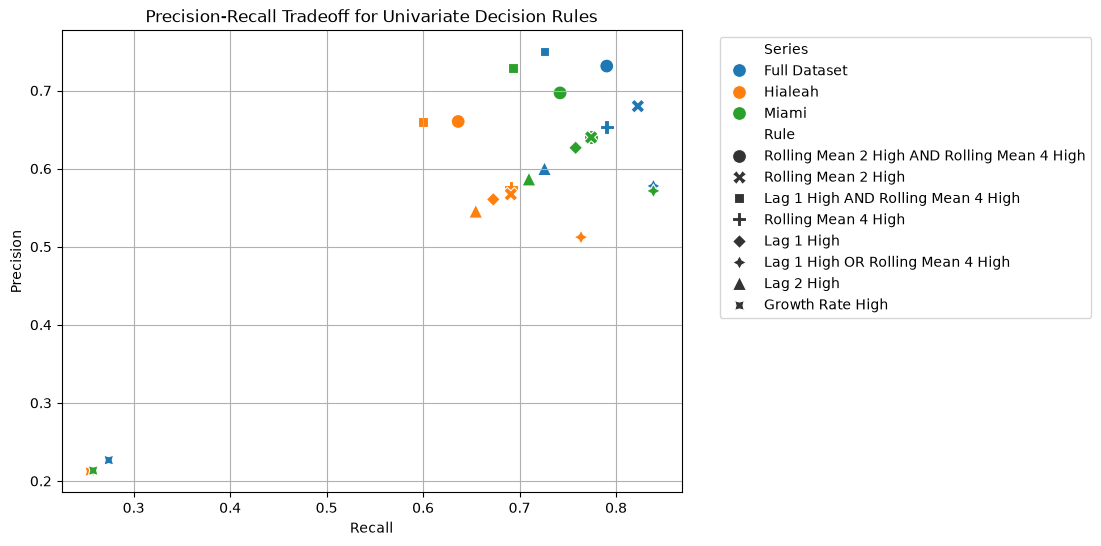

In [68]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=combined_rule_results,
    x="Recall",
    y="Precision",
    hue="Series",
    style="Rule",
    s=100
)

plt.title("Precision-Recall Tradeoff for Univariate Decision Rules")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [69]:
def plot_rule_confusion_matrix(df, predictions, best_rule_name, series_name, outbreak_col="outbreak_80"):
    """
    Plots confusion matrix for the best decision rule.
    """
    y_true = df[outbreak_col].values
    y_pred = predictions[best_rule_name]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Normal", "Pred Outbreak"],
        yticklabels=["Actual Normal", "Actual Outbreak"]
    )

    plt.title(f"Confusion Matrix — {best_rule_name} — {series_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

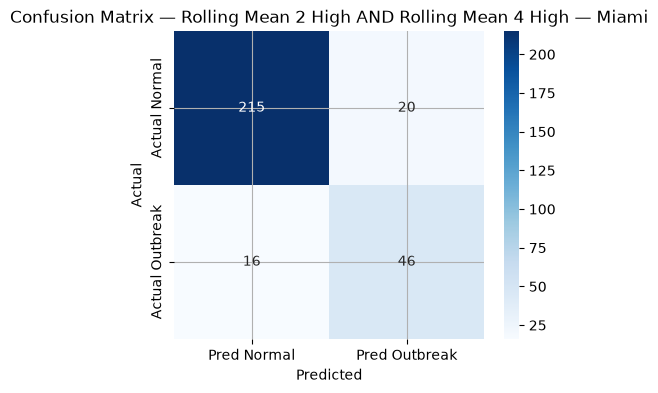

In [70]:
best_miami_rule = miami_rule_results.iloc[0]["Rule"]

plot_rule_confusion_matrix(
    miami_lag_df,
    miami_rule_predictions,
    best_rule_name=best_miami_rule,
    series_name="Miami",
    outbreak_col="outbreak_80"
)

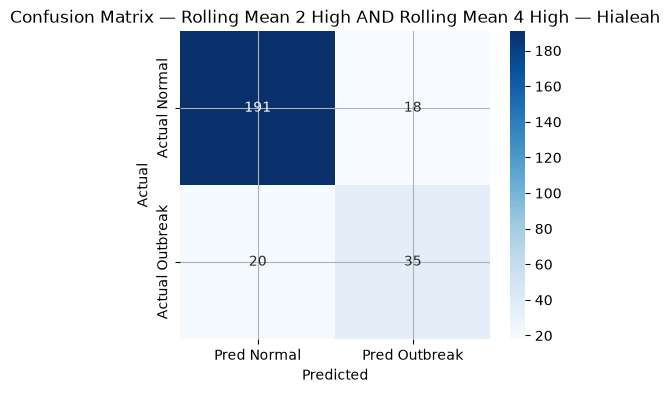

In [71]:
best_hialeah_rule = hialeah_rule_results.iloc[0]["Rule"]

plot_rule_confusion_matrix(
    hialeah_lag_df,
    hialeah_rule_predictions,
    best_rule_name=best_hialeah_rule,
    series_name="Hialeah",
    outbreak_col="outbreak_80"
)

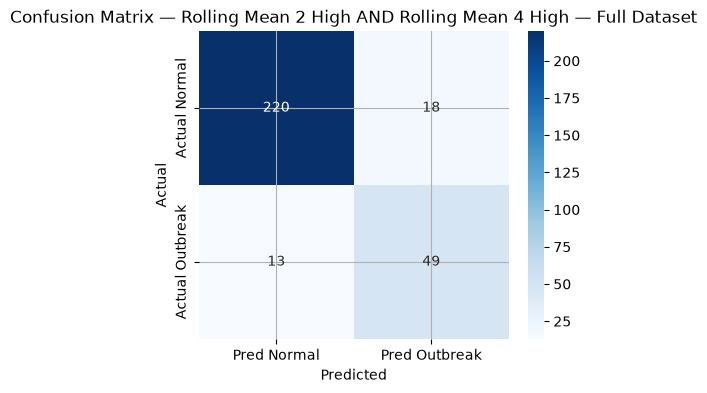

In [72]:
best_full_rule = full_rule_results.iloc[0]["Rule"]

plot_rule_confusion_matrix(
    full_lag_df,
    full_rule_predictions,
    best_rule_name=best_full_rule,
    series_name="Full Dataset",
    outbreak_col="outbreak_80"
)

In [73]:
decision_thresholds_df = pd.DataFrame([
    {"Series": "Miami", **miami_rule_thresholds},
    {"Series": "Hialeah", **hialeah_rule_thresholds},
    {"Series": "Full Dataset", **full_rule_thresholds}
])

decision_thresholds_df

,Series,lag_1_threshold,lag_2_threshold,rolling_mean_2_threshold,rolling_mean_4_threshold,growth_rate_1_threshold
0,Miami,1503.00,1503.00,1431.500,1448.2500,0.531323
1,Hialeah,273.25,280.50,262.500,285.8125,0.806418
2,Full Dataset,3689.25,3689.25,3398.625,3395.7500,0.474186


In [74]:
decision_thresholds_df.style.format({
    "lag_1_threshold": "{:.2f}",
    "lag_2_threshold": "{:.2f}",
    "rolling_mean_2_threshold": "{:.2f}",
    "rolling_mean_4_threshold": "{:.2f}",
    "growth_rate_1_threshold": "{:.2f}"
})

,Series,lag_1_threshold,lag_2_threshold,rolling_mean_2_threshold,rolling_mean_4_threshold,growth_rate_1_threshold
0,Miami,1503.00,1503.00,1431.50,1448.25,0.53
1,Hialeah,273.25,280.50,262.50,285.81,0.81
2,Full Dataset,3689.25,3689.25,3398.62,3395.75,0.47


In [75]:
def plot_outbreak_prediction_timeline(
    df,
    predictions,
    best_rule_name,
    series_name,
    outbreak_col="outbreak_80"
):
    """
    Plots actual outbreak weeks vs predicted outbreak weeks.
    """

    plot_df = df.copy()

    plot_df["actual_outbreak"] = plot_df[outbreak_col]
    plot_df["predicted_outbreak"] = predictions[best_rule_name]

    plt.figure(figsize=(15, 5))

    # mosquito counts
    plt.plot(
        plot_df.index,
        plot_df["mosquito_count"],
        label="Mosquito Count",
        linewidth=1.5
    )

    # actual outbreaks
    actual_points = plot_df[plot_df["actual_outbreak"] == 1]

    plt.scatter(
        actual_points.index,
        actual_points["mosquito_count"],
        color="red",
        label="Actual Outbreak",
        s=50
    )

    # predicted outbreaks
    predicted_points = plot_df[plot_df["predicted_outbreak"] == 1]

    plt.scatter(
        predicted_points.index,
        predicted_points["mosquito_count"],
        color="green",
        marker="x",
        label="Predicted Outbreak",
        s=60
    )

    plt.title(
        f"Actual vs Predicted Outbreak Weeks — {best_rule_name} — {series_name}"
    )

    plt.xlabel("Date")
    plt.ylabel("Mosquito Count")

    plt.legend()

    plt.show()

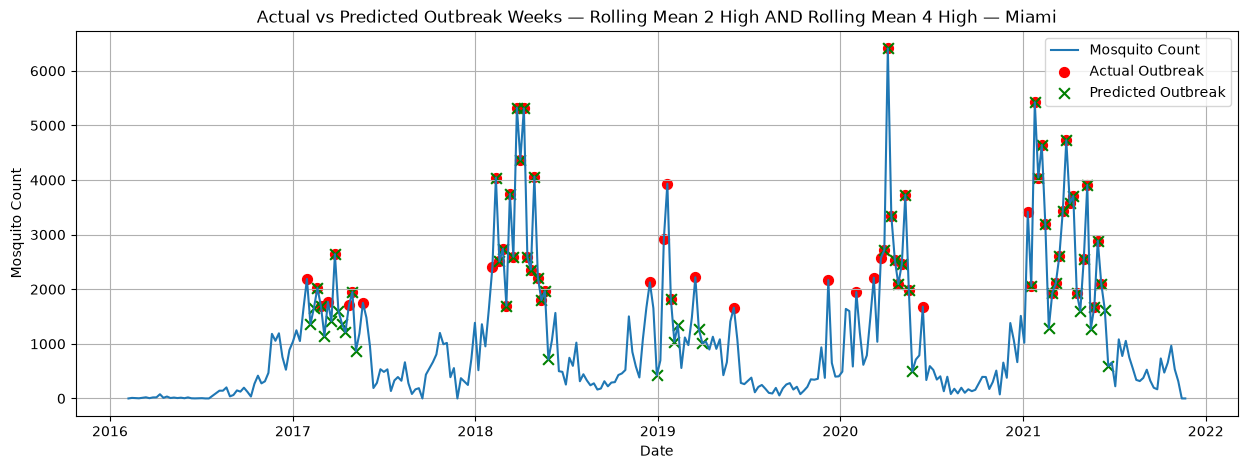

In [76]:
plot_outbreak_prediction_timeline(
    miami_lag_df,
    miami_rule_predictions,
    best_rule_name=best_miami_rule,
    series_name="Miami"
)

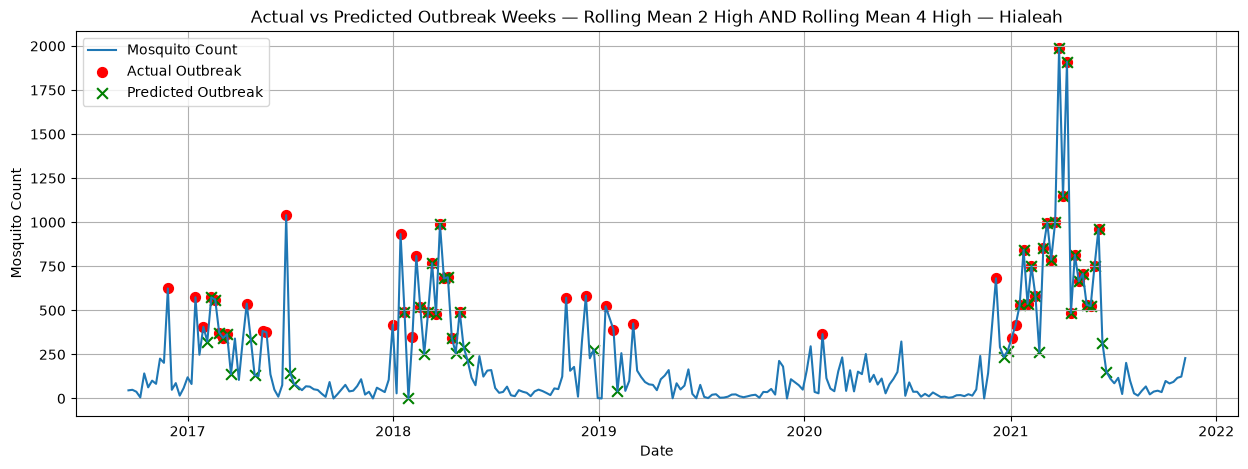

In [77]:
plot_outbreak_prediction_timeline(
    hialeah_lag_df,
    hialeah_rule_predictions,
    best_rule_name=best_hialeah_rule,
    series_name="Hialeah"
)

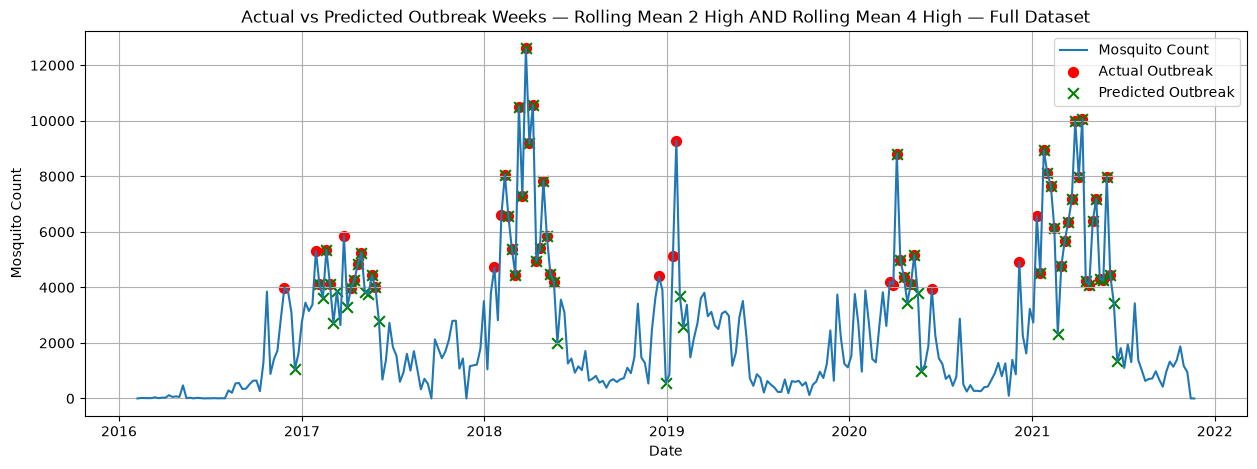

In [78]:
plot_outbreak_prediction_timeline(
    full_lag_df,
    full_rule_predictions,
    best_rule_name=best_full_rule,
    series_name="Full Dataset"
)

In [79]:
def create_lead_time_labels(df, outbreak_col="outbreak_80", horizons=[1, 2, 4]):
    """
    Creates future outbreak labels.

    For horizon h:
    outbreak_h_week_ahead = 1 if an outbreak occurs h weeks later.
    """
    df = df.copy()

    for h in horizons:
        df[f"outbreak_{h}wk_ahead"] = df[outbreak_col].shift(-h)

    return df.dropna()

In [80]:
horizons = [1, 2, 4]

miami_lead_df = create_lead_time_labels(
    miami_lag_df,
    outbreak_col="outbreak_80",
    horizons=horizons
)

hialeah_lead_df = create_lead_time_labels(
    hialeah_lag_df,
    outbreak_col="outbreak_80",
    horizons=horizons
)

full_lead_df = create_lead_time_labels(
    full_lag_df,
    outbreak_col="outbreak_80",
    horizons=horizons
)

print("Miami lead dataframe:", miami_lead_df.shape)
print("Hialeah lead dataframe:", hialeah_lead_df.shape)
print("Full dataset lead dataframe:", full_lead_df.shape)

Miami lead dataframe: (293, 14)
Hialeah lead dataframe: (260, 14)
Full dataset lead dataframe: (296, 14)


In [81]:
def evaluate_lead_time_rules(df, series_name, horizons=[1, 2, 4]):
    """
    Evaluates simple univariate decision rules for future outbreak
    detection at different lead times.
    """

    results = []

    # Rule thresholds based on current/past mosquito features
    lag1_threshold = df["lag_1"].quantile(0.75)
    lag2_threshold = df["lag_2"].quantile(0.75)
    rolling2_threshold = df["rolling_mean_2"].quantile(0.75)
    rolling4_threshold = df["rolling_mean_4"].quantile(0.75)
    growth_threshold = df["growth_rate_1"].quantile(0.75)

    rule_predictions = {
        "Lag 1 High": (df["lag_1"] >= lag1_threshold).astype(int),
        "Lag 2 High": (df["lag_2"] >= lag2_threshold).astype(int),
        "Rolling Mean 2 High": (df["rolling_mean_2"] >= rolling2_threshold).astype(int),
        "Rolling Mean 4 High": (df["rolling_mean_4"] >= rolling4_threshold).astype(int),
        "Growth Rate High": (df["growth_rate_1"] >= growth_threshold).astype(int),

        "Rolling Mean 2 High AND Rolling Mean 4 High": (
            (df["rolling_mean_2"] >= rolling2_threshold) &
            (df["rolling_mean_4"] >= rolling4_threshold)
        ).astype(int),

        "Lag 1 High AND Rolling Mean 4 High": (
            (df["lag_1"] >= lag1_threshold) &
            (df["rolling_mean_4"] >= rolling4_threshold)
        ).astype(int),

        "Lag 1 High OR Rolling Mean 4 High": (
            (df["lag_1"] >= lag1_threshold) |
            (df["rolling_mean_4"] >= rolling4_threshold)
        ).astype(int)
    }

    for h in horizons:
        future_col = f"outbreak_{h}wk_ahead"
        y_true = df[future_col].astype(int).values

        for rule_name, y_pred_series in rule_predictions.items():
            y_pred = y_pred_series.values

            results.append({
                "Series": series_name,
                "Lead Time (weeks)": h,
                "Rule": rule_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "Precision": precision_score(y_true, y_pred, zero_division=0),
                "Recall": recall_score(y_true, y_pred, zero_division=0),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Predicted Outbreak Weeks": int(np.sum(y_pred)),
                "Actual Future Outbreak Weeks": int(np.sum(y_true))
            })

    return pd.DataFrame(results)

In [82]:
miami_lead_results = evaluate_lead_time_rules(
    miami_lead_df,
    series_name="Miami",
    horizons=horizons
)

miami_lead_results.sort_values(
    ["Lead Time (weeks)", "F1"],
    ascending=[True, False]
)

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
2,Miami,1,Rolling Mean 2 High,0.856655,0.635135,0.758065,0.691176,74,62
5,Miami,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.863481,0.671875,0.693548,0.682540,64,62
3,Miami,1,Rolling Mean 4 High,0.849829,0.621622,0.741935,0.676471,74,62
7,Miami,1,Lag 1 High OR Rolling Mean 4 High,0.829352,0.566667,0.822581,0.671053,90,62
6,Miami,1,Lag 1 High AND Rolling Mean 4 High,0.856655,0.672414,0.629032,0.650000,58,62
0,Miami,1,Lag 1 High,0.836177,0.594595,0.709677,0.647059,74,62
1,Miami,1,Lag 2 High,0.822526,0.567568,0.677419,0.617647,74,62
4,Miami,1,Growth Rate High,0.645051,0.216216,0.258065,0.235294,74,62
13,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.856655,0.656250,0.677419,0.666667,64,62
11,Miami,2,Rolling Mean 4 High,0.843003,0.608108,0.725806,0.661765,74,62


In [83]:
hialeah_lead_results = evaluate_lead_time_rules(
    hialeah_lead_df,
    series_name="Hialeah",
    horizons=horizons
)

hialeah_lead_results.sort_values(
    ["Lead Time (weeks)", "F1"],
    ascending=[True, False]
)

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
5,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850000,0.653846,0.618182,0.635514,52,55
3,Hialeah,1,Rolling Mean 4 High,0.830769,0.584615,0.690909,0.633333,65,55
6,Hialeah,1,Lag 1 High AND Rolling Mean 4 High,0.846154,0.653061,0.581818,0.615385,49,55
7,Hialeah,1,Lag 1 High OR Rolling Mean 4 High,0.792308,0.506173,0.745455,0.602941,81,55
2,Hialeah,1,Rolling Mean 2 High,0.815385,0.553846,0.654545,0.600000,65,55
1,Hialeah,1,Lag 2 High,0.811538,0.545455,0.654545,0.595041,66,55
0,Hialeah,1,Lag 1 High,0.807692,0.538462,0.636364,0.583333,65,55
4,Hialeah,1,Growth Rate High,0.607692,0.138462,0.163636,0.150000,65,55
11,Hialeah,2,Rolling Mean 4 High,0.846154,0.615385,0.727273,0.666667,65,55
13,Hialeah,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.857692,0.673077,0.636364,0.654206,52,55


In [84]:
full_lead_results = evaluate_lead_time_rules(
    full_lead_df,
    series_name="Full Dataset",
    horizons=horizons
)

full_lead_results.sort_values(
    ["Lead Time (weeks)", "F1"],
    ascending=[True, False]
)

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
5,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
2,Full Dataset,1,Rolling Mean 2 High,0.858108,0.635135,0.758065,0.691176,74,62
6,Full Dataset,1,Lag 1 High AND Rolling Mean 4 High,0.871622,0.700000,0.677419,0.688525,60,62
3,Full Dataset,1,Rolling Mean 4 High,0.851351,0.621622,0.741935,0.676471,74,62
0,Full Dataset,1,Lag 1 High,0.844595,0.608108,0.725806,0.661765,74,62
7,Full Dataset,1,Lag 1 High OR Rolling Mean 4 High,0.824324,0.556818,0.790323,0.653333,88,62
1,Full Dataset,1,Lag 2 High,0.837838,0.594595,0.709677,0.647059,74,62
4,Full Dataset,1,Growth Rate High,0.635135,0.189189,0.225806,0.205882,74,62
13,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858108,0.651515,0.693548,0.671875,66,62
10,Full Dataset,2,Rolling Mean 2 High,0.844595,0.608108,0.725806,0.661765,74,62


In [85]:
combined_lead_results = pd.concat([
    miami_lead_results,
    hialeah_lead_results,
    full_lead_results
]).reset_index(drop=True)

combined_lead_results = combined_lead_results.sort_values(
    ["Series", "Lead Time (weeks)", "F1"],
    ascending=[True, True, False]
).reset_index(drop=True)

combined_lead_results

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
1,Full Dataset,1,Rolling Mean 2 High,0.858108,0.635135,0.758065,0.691176,74,62
2,Full Dataset,1,Lag 1 High AND Rolling Mean 4 High,0.871622,0.700000,0.677419,0.688525,60,62
3,Full Dataset,1,Rolling Mean 4 High,0.851351,0.621622,0.741935,0.676471,74,62
4,Full Dataset,1,Lag 1 High,0.844595,0.608108,0.725806,0.661765,74,62
...,...,...,...,...,...,...,...,...,...
67,Miami,4,Rolling Mean 2 High AND Rolling Mean 4 High,0.808874,0.546875,0.564516,0.555556,64,62
68,Miami,4,Rolling Mean 4 High,0.788396,0.500000,0.596774,0.544118,74,62
69,Miami,4,Lag 1 High AND Rolling Mean 4 High,0.808874,0.551724,0.516129,0.533333,58,62
70,Miami,4,Lag 2 High,0.767918,0.459459,0.548387,0.500000,74,62


In [86]:
combined_lead_results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.872,0.682,0.726,0.703,66,62
1,Full Dataset,1,Rolling Mean 2 High,0.858,0.635,0.758,0.691,74,62
2,Full Dataset,1,Lag 1 High AND Rolling Mean 4 High,0.872,0.700,0.677,0.689,60,62
3,Full Dataset,1,Rolling Mean 4 High,0.851,0.622,0.742,0.676,74,62
4,Full Dataset,1,Lag 1 High,0.845,0.608,0.726,0.662,74,62
5,Full Dataset,1,Lag 1 High OR Rolling Mean 4 High,0.824,0.557,0.790,0.653,88,62
6,Full Dataset,1,Lag 2 High,0.838,0.595,0.710,0.647,74,62
7,Full Dataset,1,Growth Rate High,0.635,0.189,0.226,0.206,74,62
8,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858,0.652,0.694,0.672,66,62
9,Full Dataset,2,Rolling Mean 2 High,0.845,0.608,0.726,0.662,74,62


In [87]:
best_lead_rules = (
    combined_lead_results
    .sort_values(
        ["Series", "Lead Time (weeks)", "F1"],
        ascending=[True, True, False]
    )
    .groupby(["Series", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_lead_rules

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
1,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858108,0.651515,0.693548,0.671875,66,62
2,Full Dataset,4,Lag 1 High,0.810811,0.540541,0.645161,0.588235,74,62
3,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850000,0.653846,0.618182,0.635514,52,55
4,Hialeah,2,Rolling Mean 4 High,0.846154,0.615385,0.727273,0.666667,65,55
5,Hialeah,4,Rolling Mean 2 High,0.830769,0.584615,0.690909,0.633333,65,55
6,Miami,1,Rolling Mean 2 High,0.856655,0.635135,0.758065,0.691176,74,62
7,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.856655,0.656250,0.677419,0.666667,64,62
8,Miami,4,Lag 1 High OR Rolling Mean 4 High,0.781570,0.488889,0.709677,0.578947,90,62


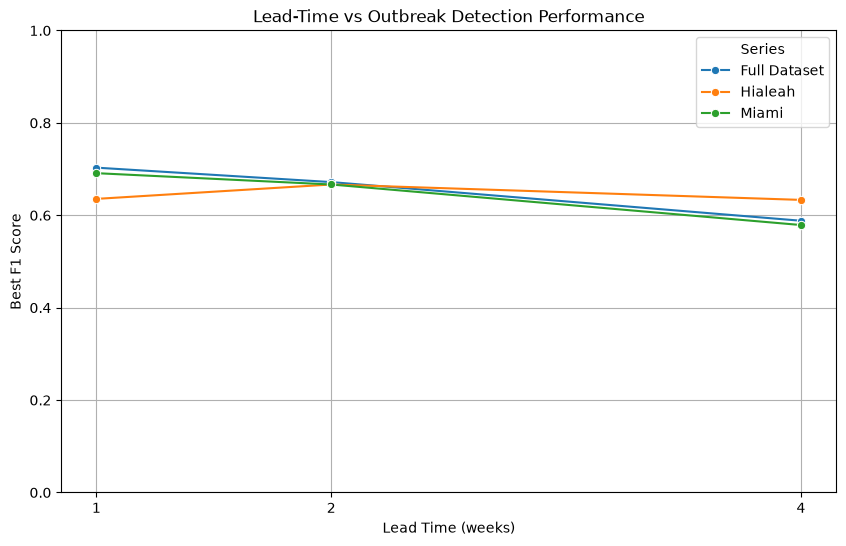

In [88]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=best_lead_rules,
    x="Lead Time (weeks)",
    y="F1",
    hue="Series",
    marker="o"
)

plt.title("Lead-Time vs Outbreak Detection Performance")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.xticks(horizons)
plt.ylim(0, 1)
plt.show()

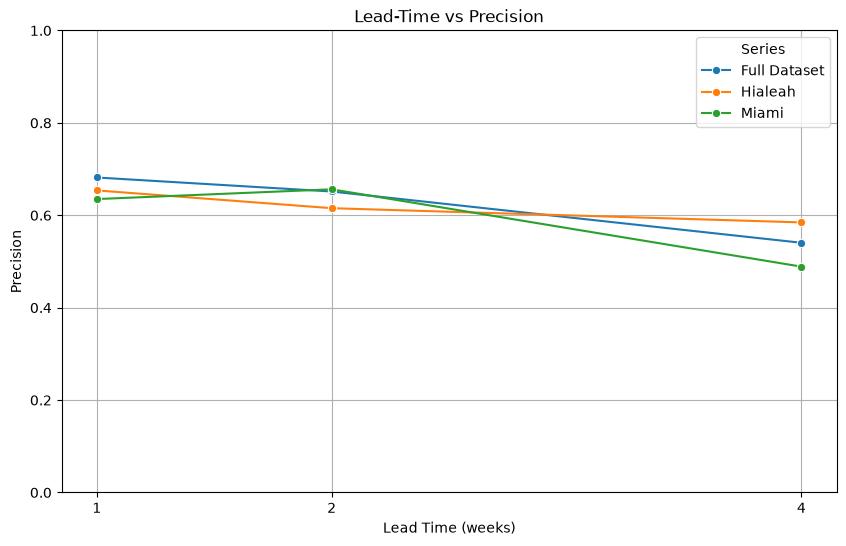

In [89]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=best_lead_rules,
    x="Lead Time (weeks)",
    y="Precision",
    hue="Series",
    marker="o"
)

plt.title("Lead-Time vs Precision")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Precision")
plt.xticks(horizons)
plt.ylim(0, 1)
plt.show()

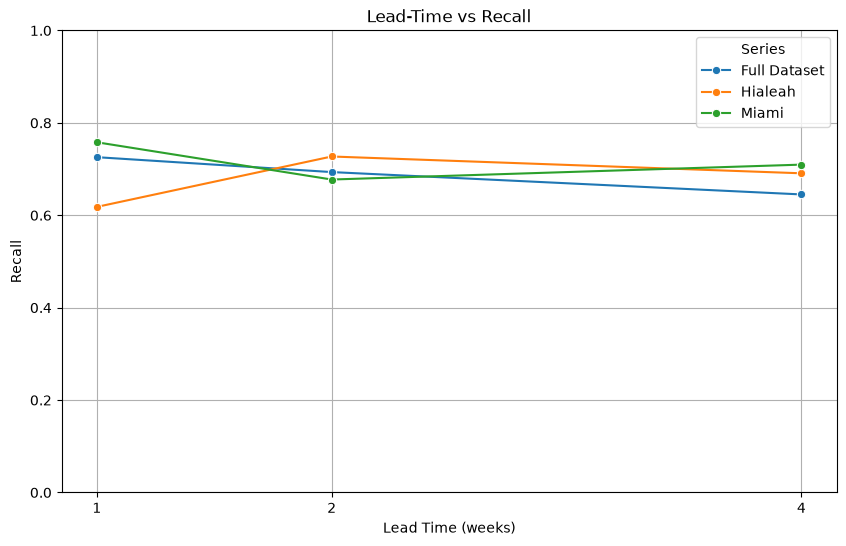

In [90]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=best_lead_rules,
    x="Lead Time (weeks)",
    y="Recall",
    hue="Series",
    marker="o"
)

plt.title("Lead-Time vs Recall")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Recall")
plt.xticks(horizons)
plt.ylim(0, 1)
plt.show()

In [91]:
best_lead_summary = best_lead_rules[
    [
        "Series",
        "Lead Time (weeks)",
        "Rule",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Predicted Outbreak Weeks",
        "Actual Future Outbreak Weeks"
    ]
].copy()

best_lead_summary

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
1,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858108,0.651515,0.693548,0.671875,66,62
2,Full Dataset,4,Lag 1 High,0.810811,0.540541,0.645161,0.588235,74,62
3,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850000,0.653846,0.618182,0.635514,52,55
4,Hialeah,2,Rolling Mean 4 High,0.846154,0.615385,0.727273,0.666667,65,55
5,Hialeah,4,Rolling Mean 2 High,0.830769,0.584615,0.690909,0.633333,65,55
6,Miami,1,Rolling Mean 2 High,0.856655,0.635135,0.758065,0.691176,74,62
7,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.856655,0.656250,0.677419,0.666667,64,62
8,Miami,4,Lag 1 High OR Rolling Mean 4 High,0.781570,0.488889,0.709677,0.578947,90,62


In [92]:
best_lead_summary.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.872,0.682,0.726,0.703,66,62
1,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858,0.652,0.694,0.672,66,62
2,Full Dataset,4,Lag 1 High,0.811,0.541,0.645,0.588,74,62
3,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850,0.654,0.618,0.636,52,55
4,Hialeah,2,Rolling Mean 4 High,0.846,0.615,0.727,0.667,65,55
5,Hialeah,4,Rolling Mean 2 High,0.831,0.585,0.691,0.633,65,55
6,Miami,1,Rolling Mean 2 High,0.857,0.635,0.758,0.691,74,62
7,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.857,0.656,0.677,0.667,64,62
8,Miami,4,Lag 1 High OR Rolling Mean 4 High,0.782,0.489,0.710,0.579,90,62


In [93]:
reference_rule = "Rolling Mean 2 High AND Rolling Mean 4 High"

reference_rule_lead_results = combined_lead_results[
    combined_lead_results["Rule"] == reference_rule
].copy()

reference_rule_lead_results

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
8,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858108,0.651515,0.693548,0.671875,66,62
20,Full Dataset,4,Rolling Mean 2 High AND Rolling Mean 4 High,0.804054,0.530303,0.564516,0.546875,66,62
24,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850000,0.653846,0.618182,0.635514,52,55
33,Hialeah,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.857692,0.673077,0.636364,0.654206,52,55
43,Hialeah,4,Rolling Mean 2 High AND Rolling Mean 4 High,0.819231,0.576923,0.545455,0.560748,52,55
49,Miami,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.863481,0.671875,0.693548,0.682540,64,62
56,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.856655,0.656250,0.677419,0.666667,64,62
67,Miami,4,Rolling Mean 2 High AND Rolling Mean 4 High,0.808874,0.546875,0.564516,0.555556,64,62


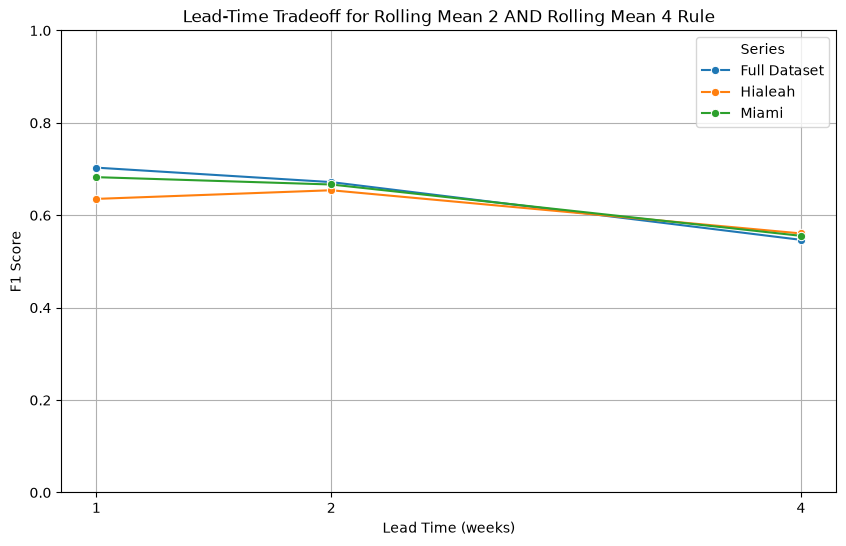

In [94]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=reference_rule_lead_results,
    x="Lead Time (weeks)",
    y="F1",
    hue="Series",
    marker="o"
)

plt.title("Lead-Time Tradeoff for Rolling Mean 2 AND Rolling Mean 4 Rule")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("F1 Score")
plt.xticks(horizons)
plt.ylim(0, 1)
plt.show()

In [95]:
cross_threshold_summary = threshold_comparison.copy()

cross_threshold_summary

,Series,80th Percentile,90th Percentile,Mean + 1 SD
0,Miami,1660.6,2515.0,2131.285855
1,Hialeah,341.8,569.8,487.187821
2,Full Dataset,3932.6,5263.2,4654.358506


In [96]:
cross_frequency_summary = combined_outbreak_summary.copy()

cross_frequency_summary

,Series,Definition,Outbreak Weeks,Percent of Weeks
0,Miami,outbreak_80,62,20.064725
1,Miami,outbreak_90,31,10.032362
2,Miami,outbreak_std,40,12.944984
3,Hialeah,outbreak_80,55,20.146520
4,Hialeah,outbreak_90,28,10.256410
5,Hialeah,outbreak_std,39,14.285714
6,Full Dataset,outbreak_80,62,20.064725
7,Full Dataset,outbreak_90,31,10.032362
8,Full Dataset,outbreak_std,40,12.944984


In [97]:
cross_duration_summary = duration_summary_df.copy()

cross_duration_summary

,Series,Outbreak Definition,Number of Outbreak Waves,Average Duration (weeks),Median Duration (weeks),Longest Duration (weeks),Average Peak Count
0,Miami,outbreak_80,20,3.100000,1.0,16,2948.050000
1,Hialeah,outbreak_80,21,2.619048,1.0,15,673.857143
2,Full Dataset,outbreak_80,16,3.875000,2.0,16,6439.812500


In [98]:
best_warning_features = (
    combined_corr
    .sort_values(["Series", "Correlation with Outbreak"], ascending=[True, False])
    .groupby("Series")
    .head(3)
    .reset_index(drop=True)
)

best_warning_features

,Series,Feature,Correlation with Outbreak
0,Full Dataset,rolling_mean_4,0.687665
1,Full Dataset,rolling_mean_2,0.683494
2,Full Dataset,lag_1,0.678566
3,Hialeah,rolling_mean_4,0.612269
4,Hialeah,rolling_mean_2,0.578953
5,Hialeah,lag_1,0.560097
6,Miami,rolling_mean_4,0.683574
7,Miami,rolling_mean_2,0.681222
8,Miami,lag_1,0.681016


In [99]:
best_decision_rules = best_rules_by_series.copy()

best_decision_rules

,Series,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Full Dataset,Rolling Mean 2 High AND Rolling Mean 4 High,0.896667,0.731343,0.790323,0.759690,67,62
1,Hialeah,Rolling Mean 2 High AND Rolling Mean 4 High,0.856061,0.660377,0.636364,0.648148,53,55
2,Miami,Rolling Mean 2 High AND Rolling Mean 4 High,0.878788,0.696970,0.741935,0.718750,66,62


In [100]:
best_lead_time_rules = best_lead_summary.copy()

best_lead_time_rules

,Series,Lead Time (weeks),Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Full Dataset,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.871622,0.681818,0.725806,0.703125,66,62
1,Full Dataset,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.858108,0.651515,0.693548,0.671875,66,62
2,Full Dataset,4,Lag 1 High,0.810811,0.540541,0.645161,0.588235,74,62
3,Hialeah,1,Rolling Mean 2 High AND Rolling Mean 4 High,0.850000,0.653846,0.618182,0.635514,52,55
4,Hialeah,2,Rolling Mean 4 High,0.846154,0.615385,0.727273,0.666667,65,55
5,Hialeah,4,Rolling Mean 2 High,0.830769,0.584615,0.690909,0.633333,65,55
6,Miami,1,Rolling Mean 2 High,0.856655,0.635135,0.758065,0.691176,74,62
7,Miami,2,Rolling Mean 2 High AND Rolling Mean 4 High,0.856655,0.656250,0.677419,0.666667,64,62
8,Miami,4,Lag 1 High OR Rolling Mean 4 High,0.781570,0.488889,0.709677,0.578947,90,62


In [101]:
summary_rows = []

series_list = ["Miami", "Hialeah", "Full Dataset"]

for series in series_list:
    
    # Thresholds
    threshold_row = cross_threshold_summary[
        cross_threshold_summary["Series"] == series
    ].iloc[0]
    
    # Frequency: 80th percentile definition
    freq_row = cross_frequency_summary[
        (cross_frequency_summary["Series"] == series) &
        (cross_frequency_summary["Definition"] == "outbreak_80")
    ].iloc[0]
    
    # Duration
    duration_row = cross_duration_summary[
        cross_duration_summary["Series"] == series
    ].iloc[0]
    
    # Best warning feature
    warning_row = best_warning_features[
        best_warning_features["Series"] == series
    ].iloc[0]
    
    # Best same-week decision rule
    decision_row = best_decision_rules[
        best_decision_rules["Series"] == series
    ].iloc[0]
    
    # Best 1-week lead-time rule
    lead_1_row = best_lead_time_rules[
        (best_lead_time_rules["Series"] == series) &
        (best_lead_time_rules["Lead Time (weeks)"] == 1)
    ].iloc[0]
    
    # Best 2-week lead-time rule
    lead_2_row = best_lead_time_rules[
        (best_lead_time_rules["Series"] == series) &
        (best_lead_time_rules["Lead Time (weeks)"] == 2)
    ].iloc[0]
    
    # Best 4-week lead-time rule
    lead_4_row = best_lead_time_rules[
        (best_lead_time_rules["Series"] == series) &
        (best_lead_time_rules["Lead Time (weeks)"] == 4)
    ].iloc[0]
    
    summary_rows.append({
        "Series": series,
        "80th Percentile Threshold": threshold_row["80th Percentile"],
        "90th Percentile Threshold": threshold_row["90th Percentile"],
        "Outbreak Weeks (%)": freq_row["Percent of Weeks"],
        "Number of Outbreak Waves": duration_row["Number of Outbreak Waves"],
        "Average Outbreak Duration": duration_row["Average Duration (weeks)"],
        "Longest Outbreak Duration": duration_row["Longest Duration (weeks)"],
        "Best Warning Feature": warning_row["Feature"],
        "Best Warning Correlation": warning_row["Correlation with Outbreak"],
        "Best Same-Week Rule": decision_row["Rule"],
        "Same-Week Rule F1": decision_row["F1"],
        "Best 1-Week F1": lead_1_row["F1"],
        "Best 2-Week F1": lead_2_row["F1"],
        "Best 4-Week F1": lead_4_row["F1"]
    })

cross_series_systems_summary = pd.DataFrame(summary_rows)

cross_series_systems_summary

,Series,80th Percentile Threshold,90th Percentile Threshold,Outbreak Weeks (%),Number of Outbreak Waves,Average Outbreak Duration,Longest Outbreak Duration,Best Warning Feature,Best Warning Correlation,Best Same-Week Rule,Same-Week Rule F1,Best 1-Week F1,Best 2-Week F1,Best 4-Week F1
0,Miami,1660.6,2515.0,20.064725,20,3.100000,16,rolling_mean_4,0.683574,Rolling Mean 2 High AND Rolling Mean 4 High,0.718750,0.691176,0.666667,0.578947
1,Hialeah,341.8,569.8,20.146520,21,2.619048,15,rolling_mean_4,0.612269,Rolling Mean 2 High AND Rolling Mean 4 High,0.648148,0.635514,0.666667,0.633333
2,Full Dataset,3932.6,5263.2,20.064725,16,3.875000,16,rolling_mean_4,0.687665,Rolling Mean 2 High AND Rolling Mean 4 High,0.759690,0.703125,0.671875,0.588235


In [102]:
cross_series_systems_summary.style.format({
    "80th Percentile Threshold": "{:.2f}",
    "90th Percentile Threshold": "{:.2f}",
    "Outbreak Weeks (%)": "{:.2f}",
    "Average Outbreak Duration": "{:.2f}",
    "Longest Outbreak Duration": "{:.0f}",
    "Best Warning Correlation": "{:.3f}",
    "Same-Week Rule F1": "{:.3f}",
    "Best 1-Week F1": "{:.3f}",
    "Best 2-Week F1": "{:.3f}",
    "Best 4-Week F1": "{:.3f}"
})

,Series,80th Percentile Threshold,90th Percentile Threshold,Outbreak Weeks (%),Number of Outbreak Waves,Average Outbreak Duration,Longest Outbreak Duration,Best Warning Feature,Best Warning Correlation,Best Same-Week Rule,Same-Week Rule F1,Best 1-Week F1,Best 2-Week F1,Best 4-Week F1
0,Miami,1660.60,2515.00,20.06,20,3.10,16,rolling_mean_4,0.684,Rolling Mean 2 High AND Rolling Mean 4 High,0.719,0.691,0.667,0.579
1,Hialeah,341.80,569.80,20.15,21,2.62,15,rolling_mean_4,0.612,Rolling Mean 2 High AND Rolling Mean 4 High,0.648,0.636,0.667,0.633
2,Full Dataset,3932.60,5263.20,20.06,16,3.88,16,rolling_mean_4,0.688,Rolling Mean 2 High AND Rolling Mean 4 High,0.760,0.703,0.672,0.588


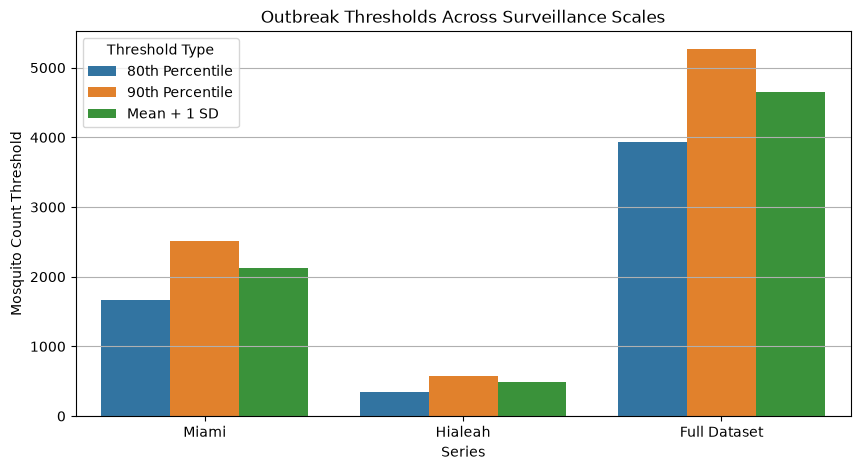

In [103]:
threshold_plot_df = cross_threshold_summary.melt(
    id_vars="Series",
    var_name="Threshold Type",
    value_name="Threshold Value"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=threshold_plot_df,
    x="Series",
    y="Threshold Value",
    hue="Threshold Type"
)

plt.title("Outbreak Thresholds Across Surveillance Scales")
plt.xlabel("Series")
plt.ylabel("Mosquito Count Threshold")
plt.legend(title="Threshold Type")
plt.show()

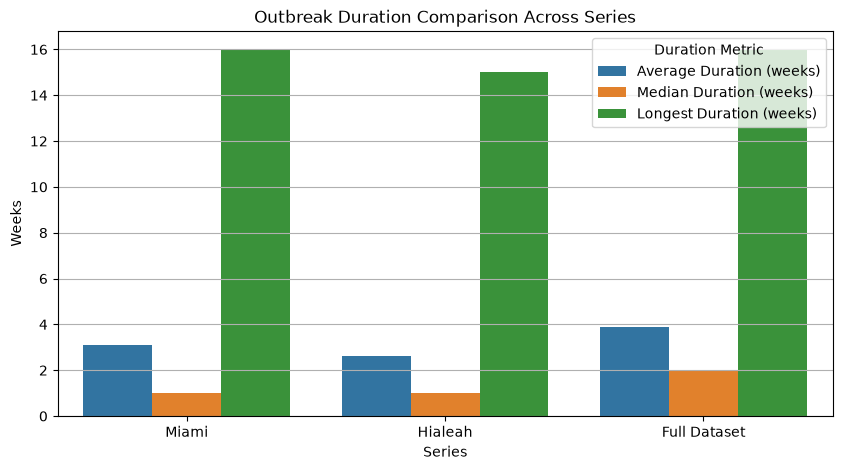

In [104]:
duration_metric_df = cross_duration_summary[
    [
        "Series",
        "Average Duration (weeks)",
        "Median Duration (weeks)",
        "Longest Duration (weeks)"
    ]
].melt(
    id_vars="Series",
    var_name="Duration Metric",
    value_name="Weeks"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=duration_metric_df,
    x="Series",
    y="Weeks",
    hue="Duration Metric"
)

plt.title("Outbreak Duration Comparison Across Series")
plt.xlabel("Series")
plt.ylabel("Weeks")
plt.legend(title="Duration Metric")
plt.show()

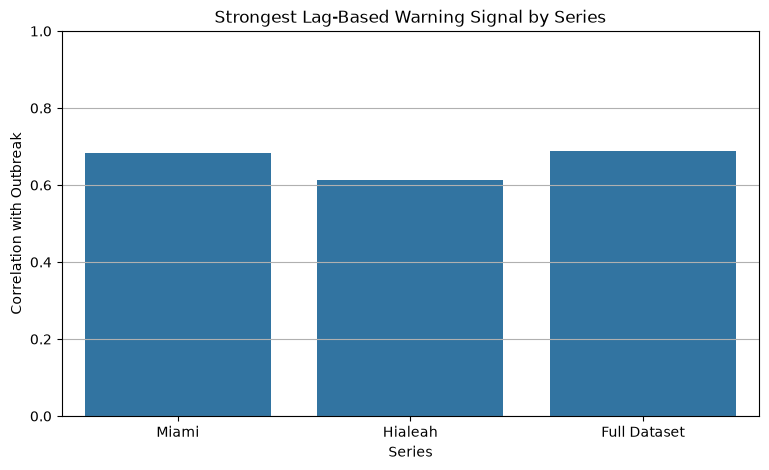

In [105]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cross_series_systems_summary,
    x="Series",
    y="Best Warning Correlation"
)

plt.title("Strongest Lag-Based Warning Signal by Series")
plt.xlabel("Series")
plt.ylabel("Correlation with Outbreak")
plt.ylim(0, 1)
plt.show()

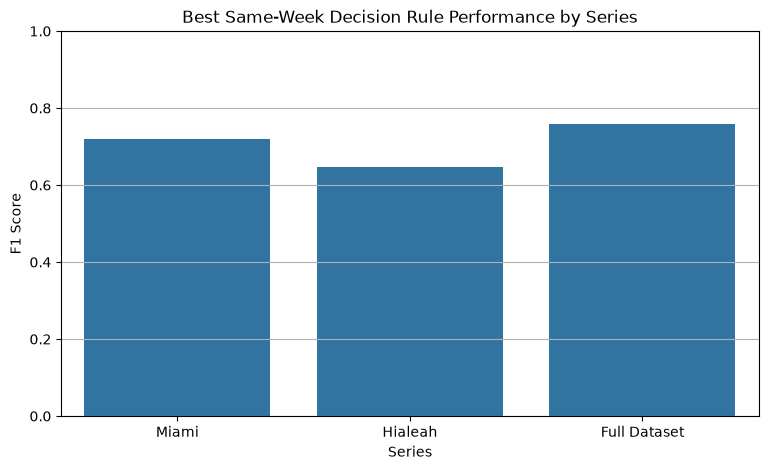

In [106]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cross_series_systems_summary,
    x="Series",
    y="Same-Week Rule F1"
)

plt.title("Best Same-Week Decision Rule Performance by Series")
plt.xlabel("Series")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

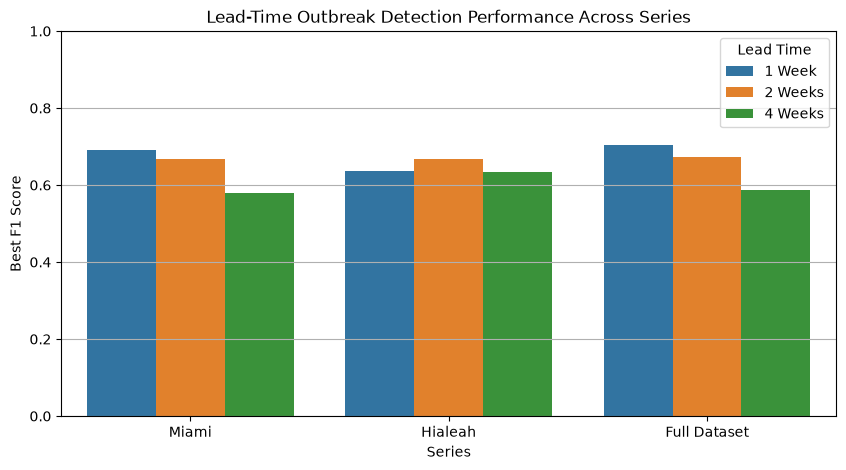

In [107]:
lead_plot_df = cross_series_systems_summary[
    [
        "Series",
        "Best 1-Week F1",
        "Best 2-Week F1",
        "Best 4-Week F1"
    ]
].melt(
    id_vars="Series",
    var_name="Lead Time",
    value_name="F1"
)

lead_plot_df["Lead Time"] = lead_plot_df["Lead Time"].replace({
    "Best 1-Week F1": "1 Week",
    "Best 2-Week F1": "2 Weeks",
    "Best 4-Week F1": "4 Weeks"
})

plt.figure(figsize=(10, 5))

sns.barplot(
    data=lead_plot_df,
    x="Series",
    y="F1",
    hue="Lead Time"
)

plt.title("Lead-Time Outbreak Detection Performance Across Series")
plt.xlabel("Series")
plt.ylabel("Best F1 Score")
plt.ylim(0, 1)
plt.legend(title="Lead Time")
plt.show()

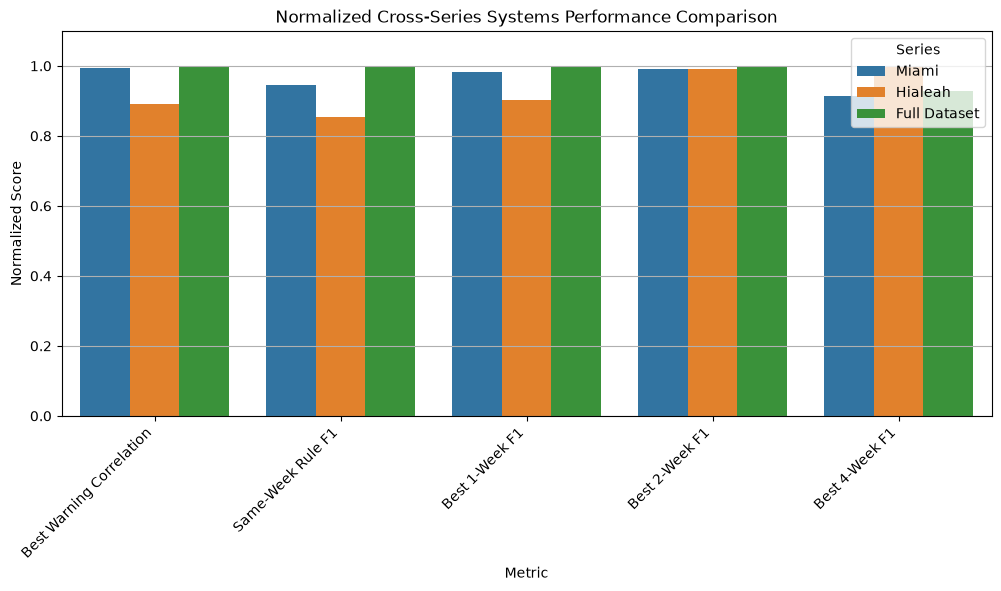

In [108]:
normalized_summary = cross_series_systems_summary.copy()

metrics_to_normalize = [
    "Best Warning Correlation",
    "Same-Week Rule F1",
    "Best 1-Week F1",
    "Best 2-Week F1",
    "Best 4-Week F1"
]

for col in metrics_to_normalize:
    max_val = normalized_summary[col].max()
    normalized_summary[col + " Normalized"] = normalized_summary[col] / max_val

normalized_plot_df = normalized_summary.melt(
    id_vars="Series",
    value_vars=[col + " Normalized" for col in metrics_to_normalize],
    var_name="Metric",
    value_name="Normalized Score"
)

normalized_plot_df["Metric"] = normalized_plot_df["Metric"].str.replace(" Normalized", "")

plt.figure(figsize=(12, 5))

sns.barplot(
    data=normalized_plot_df,
    x="Metric",
    y="Normalized Score",
    hue="Series"
)

plt.title("Normalized Cross-Series Systems Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Normalized Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.1)
plt.legend(title="Series")
plt.show()

In [109]:
cross_series_systems_summary.to_csv(
    "univariate_cross_series_systems_summary.csv",
    index=False
)

combined_rule_results.to_csv(
    "univariate_decision_rule_results.csv",
    index=False
)

combined_lead_results.to_csv(
    "univariate_lead_time_results.csv",
    index=False
)

combined_pre_outbreak_summary.to_csv(
    "univariate_pre_outbreak_warning_signals.csv",
    index=False
)

duration_summary_df.to_csv(
    "univariate_outbreak_duration_summary.csv",
    index=False
)